<a href="https://colab.research.google.com/github/LCaravaggio/Happiness_Polarization/blob/main/Event_Studies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cargar de datos

In [1]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import re

BASE = "https://www.latinobarometro.org"
INDEX = f"{BASE}/agregados"

headers = {
    "User-Agent": "Mozilla/5.0"
}

# =========================
# 1. obtener páginas de cada ola
# =========================

html = requests.get(INDEX, headers=headers).text
soup = BeautifulSoup(html, "html.parser")

wave_pages = []

for a in soup.find_all("a", href=True):

    href = a["href"]

    # links tipo /latinobarometro-2023
    if re.search(r"latinobarometro-\d{4}$", href):

        full = urljoin(BASE, href)
        wave_pages.append(full)

wave_pages = sorted(set(wave_pages))

print("Olas encontradas:")
for w in wave_pages:
    print(w)

# =========================
# 2. entrar a cada ola y buscar ZIP de Stata
# =========================

stata_links = []

for page in wave_pages:

    print(f"\nRevisando {page}")

    try:
        html = requests.get(page, headers=headers, timeout=20).text
        soup = BeautifulSoup(html, "html.parser")

        for a in soup.find_all("a", href=True):

            href = a["href"]
            text = a.get_text(" ", strip=True).lower()

            full = urljoin(page, href)

            # queremos ZIPs relacionados con Stata
            if (
                ".zip" in href.lower()
                and (
                    "stata" in href.lower()
                    or "dta" in href.lower()
                    or "stata" in text
                )
            ):
                stata_links.append(full)

    except Exception as e:
        print("Error:", e)

# limpiar duplicados
stata_links = sorted(set(stata_links))

print("\nZIPs Stata encontrados:\n")

for l in stata_links:
    print(l)

Olas encontradas:
https://www.latinobarometro.org/latinobarometro-1995
https://www.latinobarometro.org/latinobarometro-1996
https://www.latinobarometro.org/latinobarometro-1997
https://www.latinobarometro.org/latinobarometro-1998
https://www.latinobarometro.org/latinobarometro-2000
https://www.latinobarometro.org/latinobarometro-2001
https://www.latinobarometro.org/latinobarometro-2002
https://www.latinobarometro.org/latinobarometro-2003
https://www.latinobarometro.org/latinobarometro-2004
https://www.latinobarometro.org/latinobarometro-2005
https://www.latinobarometro.org/latinobarometro-2006
https://www.latinobarometro.org/latinobarometro-2007
https://www.latinobarometro.org/latinobarometro-2008
https://www.latinobarometro.org/latinobarometro-2009
https://www.latinobarometro.org/latinobarometro-2010
https://www.latinobarometro.org/latinobarometro-2011
https://www.latinobarometro.org/latinobarometro-2013
https://www.latinobarometro.org/latinobarometro-2015
https://www.latinobarometro.

In [2]:
import requests

import shutil
import os

# borrar carpeta rota
shutil.rmtree("latinobarometro", ignore_errors=True)

# recrear
os.makedirs("latinobarometro", exist_ok=True)

for link in stata_links:

    filename = link.split("/")[-1]
    filepath = os.path.join("latinobarometro", filename)

    print("Descargando:", filename)

    r = requests.get(link)

    with open(filepath, "wb") as f:
        f.write(r.content)

Descargando: latinobarometro-1995-dta.zip
Descargando: latinobarometro-1996-dta.zip
Descargando: latinobarometro-1997-dta.zip
Descargando: latinobarometro-1998-dta.zip
Descargando: latinobarometro-2000-dta.zip
Descargando: latinobarometro-2001-dta.zip
Descargando: latinobarometro-2002-dta.zip
Descargando: latinobarometro-2003-dta.zip
Descargando: latinobarometro-2004-dta.zip
Descargando: latinobarometro-2005-dta.zip
Descargando: latinobarometro-2006-dta.zip
Descargando: latinobarometro-2007-dta.zip
Descargando: latinobarometro-2008-dta.zip
Descargando: latinobarometro-2009-dta.zip
Descargando: latinobarometro-2010-dta.zip
Descargando: latinobarometro-2011-dta.zip
Descargando: latinobarometro-2013-dta.zip
Descargando: latinobarometro-2015-dta.zip
Descargando: latinobarometro2016-dta.zip
Descargando: latinobarometro2017-dta.zip
Descargando: latinobarometro-2018-eng-stata-v20190303.zip
Descargando: latinobarometro-2018-esp-dta-v20190303.zip
Descargando: latinobarometro-2020-eng-stata-v1-0

In [3]:
!mkdir -p latinobarometro/unzipped

!find latinobarometro -name "*.zip" -exec unzip -o {} -d latinobarometro/unzipped \;

Archive:  latinobarometro/latinobarometro-1995-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_1995_Esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_1995_Eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_1995_datos_esp_v2014_06_27.dta  
  inflating: latinobarometro/unzipped/Latinobarometro_1995_data_english_v2014_06_27.dta  
Archive:  latinobarometro/latinobarometro-2000-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2000_Eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2000_Esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2000_datos_esp_v2014_06_27.dta  
  inflating: latinobarometro/unzipped/Latinobarometro_2000_datos_eng_v2014_06_27.dta  
Archive:  latinobarometro/latinobarometro-2005-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2005_esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2005_eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2005_datos_esp_v

In [4]:
# =========================
# mapeo armonizado
# =========================

varmap = {

    # ---------------------------------
    # satisfacción con la vida
    # ---------------------------------

    "life_satisfaction": {

        1997: "nsp10",
        2000: "P8ST",
        2001: "p41st",
        2002: "p1wvs",
        2003: "p19st",
        2004: "p1st",
        2005: "p1st",
        2006: "p1st_a",
        2007: "p1st",
        2008: "p27st",
        2009: "p1st",
        2010: "P1ST",
        2011: "P1ST",
        2013: "P1ST",
        2015: "P1ST",
        2016: "P1ST",
        2017: "P1ST",
        2018: "P1STC",
        2020: "p1st",
        2023: "P1ST",
        2024: "P1ST"
    },


    # ---------------------------------
    # situación económica actual del país
    # ---------------------------------

    "econ_country": {

        1995: "p1",
        1996: "p1",
        1997: "sp1",
        1998: "sp1",
        2000: "P1ST",
        2001: "p1st",
        2002: "p2sta",
        2003: "p1st",
        2004: "p2st",
        2005: "p2st",
        2006: "p2st",
        2007: "p100st",
        2008: "p4st",
        2009: "p3st_a",
        2010: "P3ST_A",
        2011: "P3ST_A",
        2013: "P3STGBS",
        2015: "P3STGBS",
        2016: "P4STGBS",
        2017: "P4STGBSC",
        2018: "P6STGBSC",
        2020: "p4stgbs",
        2023: "P5STGBS",
        2024: "P6STGBS"
    },

    # ---------------------------------
    # confianza interpersonal
    # ---------------------------------

    "trust_people": {

        1996: "p12",
        1997: "sp21",
        1998: "sp20",
        2000: "P17ST",
        2001: "p42st",
        2002: "p29st",
        2003: "p20st",
        2004: "p43st",
        2005: "p14st",
        2006: "p45st",
        2007: "p23st",
        2008: "p21wvsst",
        2009: "p58st",
        2010: "P55ST",
        2011: "P25ST",
        2013: "P29STGBS",
        2015: "P15STGBS",
        2016: "P12STGBS",
        2017: "P13STGBS",
        2018: "P11STGBS",
        2020: "p9stgbs",
        2023: "P9STGBS",
        2024: "P10STGBS"
    },

    # ---------------------------------
    # ciudad
    # ---------------------------------

    "city": {
        1997: "ciudad",
        2000: "ciudad",
        2001: "ciudad",
        2003: "ciudad",
        2004: "Ciudad",
        2005: "ciudad",
        2006: "ciudad",
        2007: "ciudad",
        2008: "ciudad",
        2009: "ciudad",
        2010: "ciudad",
        2011: "ciudad",
        2013: "ciudad",
        2015: "ciudad",
        2016: "ciudad",
        2017: "ciudad",
        2018: "CIUDAD",
        2020: "ciudad",
        2023: "ciudad",
        2024: "CIUDAD"
    },

    # ---------------------------------
    # interés en política
    # ---------------------------------

    "interest_politics": {

        1995: "p62",
        1996: "p64",
        1997: "sp41",
        1998: "sp36",
        2000: "P63ST",
        2001: "p56st",
        2003: "p61st",
        2004: "p29st",
        2005: "p37st",
        2007: "p59st",
        2009: "p32st",
        2010: "P23ST",
        2013: "P20STGBS",
        2020: "p46stgbs",
        2023: "P40STGBS",
        2024: "P36STGBS",

    },

    # ---------------------------------
    # sexo
    # ---------------------------------

    "sex": {

        1995: "s1",
        1996: "s1",
        1997: "s1",
        1998: "s1",
        2000: "S1",
        2001: "s1",
        2002: "s1",
        2003: "s1",
        2004: "s1",
        2005: "s6",
        2006: "s6",
        2007: "s10",
        2008: "s8",
        2009: "s5",
        2010: "S7",
        2011: "S16",
        2013: "S10",
        2015: "S12",
        2016: "sexo",
        2017: "sexo",
        2018: "SEXO",
        2020: "sexo",
        2023: "sexo",
        2024: "SEXO"
    },

    # ---------------------------------
    # edad
    # ---------------------------------

    "age": {

        1995: "s2",
        1996: "s2",
        1997: "s2",
        1998: "s2",
        2000: "S2",
        2001: "s2",
        2002: "s2",
        2003: "s2",
        2004: "s2",
        2005: "s7",
        2006: "s7",
        2007: "s11",
        2008: "s9",
        2009: "s6",
        2010: "S8",
        2011: "S17",
        2013: "S11",
        2015: "S13",
        2016: "edad",
        2017: "edad",
        2018: "EDAD",
        2020: "edad",
        2023: "edad",
        2024: "EDAD"
    },

    # ---------------------------------
    # estado civil
    # ---------------------------------

    "civil_status": {

        1995: "s6",
        1996: "s5",
        1997: "s5",
        1998: "s5",
        2000: "S4",
        2001: "s4",
        2002: "s4",
        2003: "s4",
        2004: "s4",
        2005: "s9",
        2006: "s9",
        2007: "s13",
        2008: "s3",
        2009: "s3",
        2010: "S5",
        2011: "S15",
        2013: "S9",
        2015: "S11",
        2016: "S5",
        2017: "S6",
        2018: "S23"
    },

    # ---------------------------------
    # izquierda-derecha
    # ---------------------------------

    "left_right": {

        1995: "p31",
        1996: "p38",
        1997: "sp56",
        1998: "sp52",
        2000: "P52ST",
        2001: "p54st",
        2002: "p64st",
        2003: "p60st",
        2004: "p87st",
        2005: "p34st",
        2006: "p47st",
        2007: "p67st",
        2008: "p56st",
        2009: "p69st",
        2010: "P60ST",
        2011: "P76ST",
        2013: "P41ST",
        2015: "P27ST",
        2016: "P17ST",
        2017: "P19STC",
        2018: "P22ST",
        2020: "p18st",
        2023: "P16ST",
        2024: "P16ST"
    },


    # ---------------------------------
    # país
    # ---------------------------------

    "country": {

        1995: "pais",
        1996: "pais",
        1997: "idenpa",
        1998: "idenpa",
        2000: "idenpa",
        2001: "idenpa",
        2002: "idenpa",
        2003: "idenpa",
        2004: "idenpa",
        2005: "idenpa",
        2006: "idenpa",
        2007: "idenpa",
        2008: "idenpa",
        2009: "idenpa",
        2010: "idenpa",
        2011: "idenpa",
        2013: "idenpa",
        2015: "idenpa",
        2016: "idenpa",
        2017: "idenpa",
        2018: "IDENPA",
        2020: "idenpa",
        2023: "idenpa",
        2024: "IDENPA"
    },

    # ---------------------------------
    # educación
    # ---------------------------------

"education": {

    1995: "s17",
    1996: "s14",
    1997: "s10",
    1998: "s11",
    2000: "S6",
    2001: "s6",
    2002: "s6",
    2003: "s6",
    2004: "s6",
    2005: "s11",
    2006: "s11",
    2007: "s15",
    2008: "s15",
    2009: "s12",
    2010: "S14",
    2011: "S21",
    2013: "S17",
    2015: "S19",
    2016: "S13",
    2017: "S14",
    2018: "S10",
    2020: "s16",
    2023: "S11",
    2024: "S11"
},

# ---------------------------------
# twitter
# ---------------------------------

"twitter": {

    2009: "S25_E",
    2010: "S27_E",
    2011: "S33ST_BE",
    2013: "P83TNCE",
    2015: "S10M_E",
    2016: "S15M_D",
    2017: "S16M_D",
    2018: "S12M.D",
    2020: "s19m_04",
    2023: "S14M_D",
    2024: "S14M.4"

},

# ---------------------------------
# Voto
# ---------------------------------
"vote": {

    1995: "p33",
    1996: "p40",
    1997: "sp58",
    1998: "sp53",
    2000: "P54ST",
    2001: "p55st",
    2002: "p45st",
    2003: "p54st",
    2004: "p30st",
    2005: "p48st",
    2006: "p38st",
    2007: "p64st",
    2008: "p61st",
    2009: "p35st",
    2010: "P29ST",
    2011: "P38ST",
    2013: "P22TGBSM",
    2015: "P23TGBSM",
    2016: "P15STGBS",
    2017: "P16STGBS",
    2018: "P21STGBS.A",
    2020: "P50STGBS_A",
    2023: "P43STGBS_A",
    2024: "P39STGBS.A"
},

# ---------------------------------
# Confianza en el Congreso
# ---------------------------------

"confianza_congreso": {
    1995: "p27i",
    1996: "p33i",
    1997: "sp63f",
    1998: "sp38f",
    2000: "P35ST_F",
    2001: "p61stf",
    2002: "p36std",
    2003: "p21stf",
    2004: "p34stf",
    2005: "p45sta",
    2006: "p24st_f",
    2007: "p24st_f",
    2008: "p28st_a",
    2009: "p26st_a",
    2010: "P20ST_A",
    2011: "P22ST_A",
    2013: "P26TGB_C",
    2015: "P16ST_F",
    2016: "P13STD",
    2017: "P14ST_D",
    2018: "P15STGBSC.D",
    2020: "p13st_d",
    2023: "P13ST_D",
    2024: "P14ST.D"
},

# ---------------------------------
# Confianza en el Gobierno
# ---------------------------------

"confianza_gobierno": {
    1995: "p27m",
    1996: "p33m",
    2002: "p34std",
    2003: "p23stg",
    2004: "p32std",
    2005: "p45stc",
    2006: "p32st_a",
    2007: "p24st_a",
    2008: "p31s_ta",
    2009: "p24st_a",
    2010: "P18ST_A",
    2011: "P20ST_A",
    2013: "P26TGB_B",
    2015: "P16ST_G",
    2016: "P13STE",
    2017: "P14ST_E",
    2018: "P15STGBSC.E",
    2020: "p13st_e",
    2023: "P13ST_E",
    2024: "P14ST.E"
},

# ---------------------------------
# Confianza en el Poder Judicial
# ---------------------------------

"confianza_judicial": {
    1995: "p27d",
    1996: "p33d",
    1997: "sp63c",
    1998: "sp38c",
    2000: "P35ST_C",
    2001: "p61stc",
    2002: "p34stc",
    2003: "p21ste",
    2004: "p34stb",
    2005: "p42std",
    2006: "p24st_a",
    2007: "p24st_d",
    2008: "p28st_b",
    2009: "p26st_b",
    2010: "P20ST_B",
    2011: "P22ST_B",
    2013: "P26TGB_E",
    2015: "P16ST_H",
    2016: "P13STF",
    2017: "P14ST_F",
    2018: "P15STGBSC.F",
    2020: "p13st_f",
    2023: "P13ST_F",
    2024: "P14ST.F"
},

# ---------------------------------
# Día
# ---------------------------------

"dia_real": {
    1997: "diareal",
    1998: "diareal",
    2000: "diareal",
    2001: "diareal",
    2002: "diareal",
    2003: "diareal",
    2004: "diareal",
    2005: "diareal",
    2006: "diareal",
    2007: "diareal",
    2008: "diareal",
    2009: "diareal",
    2010: "diareal",
    2011: "diareal",
    2013: "diareal",
    2015: "diareal",
    2016: "diareal",
    2017: "diareal",
    2018: "DIAREAL",
    2020: "diareal",
    2023: "diareal",
    2024: "DIAREAL",
},


# ---------------------------------
# Mes
# ---------------------------------

"mes_real": {
    1997: "mesreal",
    1998: "mesreal",
    2000: "mesreal",
    2001: "mesreal",
    2002: "mesreal",
    2003: "mesreal",
    2004: "mesreal",
    2005: "mesreal",
    2006: "mesreal",
    2007: "mesreal",
    2008: "mesreal",
    2009: "mesreal",
    2010: "mesreal",
    2011: "mesreal",
    2013: "mesreal",
    2015: "mesreal",
    2016: "mesreal",
    2017: "mesreal",
    2018: "MESREAL",
    2020: "mesreal",
    2023: "mesreal",
    2024: "MESREAL",
}


}

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path("latinobarometro/unzipped")

# =========================
# buscar archivos
# =========================

dta_files = sorted([
    f for f in BASE.rglob("*.dta")
    if "eng" not in f.name.lower()
])

# =========================
# detectar ola
# =========================

def detect_wave(path):

    m = re.search(r"(19|20)\d{2}", path.name)

    if m:
        return int(m.group())

    return np.nan

# =========================
# verificar SOLO faltantes
# =========================

for file in dta_files:

    try:

        wave = detect_wave(file)

        # leer pocas filas
        tmp_reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        tmp = tmp_reader.read(5)

        existing_cols = set(tmp.columns)

        missing = []

        # -------------------------
        # revisar varmap
        # -------------------------

        for new_name, mapping in varmap.items():

            if wave not in mapping:
                continue

            old_var = mapping[wave]

            if old_var not in existing_cols:

                missing.append(
                    f"{new_name} -> {old_var}"
                )

        # -------------------------
        # imprimir sólo si faltan
        # -------------------------

        if len(missing) > 0:

            print("\n" + "="*60)
            print(f"{file.name} | wave={wave}")

            for m in missing:
                print("FALTA:", m)

        del tmp
        del tmp_reader

    except Exception as e:

        print(f"\nERROR en {file.name}")
        print(e)

In [6]:
def detect_id(df):

    for c in [
        "IDNUM",
        "idnum",
        "Idnum",
        "id_num",
        "NUMINVES",
        "numinves",
        "folio",
        "FOLIO",
        "numero",
        "NUMERO"
    ]:

        if c in df.columns:
            return c

    return None

# =========================
# merge final
# =========================

master = pd.DataFrame()

for file in dta_files:

    try:

        wave = detect_wave(file)

        print(f"Cargando {file.name} | wave={wave}")

        # -------------------------
        # leer nombres columnas
        # -------------------------

        tmp_reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        tmp = tmp_reader.read(5)

        # normalizar nombres
        tmp.columns = (
            tmp.columns
            .str.strip()
        )

        existing_cols = set(tmp.columns)

        # -------------------------
        # detectar ID
        # -------------------------

        id_col = detect_id(tmp)

        if id_col is None:

            print("  -> no se encontró ID")
            continue

        # -------------------------
        # variables disponibles
        # -------------------------

        wave_vars = {}

        for new_name, mapping in varmap.items():

            if wave not in mapping:
                continue

            old_var = mapping[wave]

            if old_var in existing_cols:

                wave_vars[new_name] = old_var

        # columnas a leer
        cols_to_read = list(
            set(wave_vars.values()) | {id_col}
        )

        # -------------------------
        # cargar datos reales
        # -------------------------

        df = pd.read_stata(
            file,
            columns=cols_to_read,
            convert_categoricals=False
        )

        # normalizar columnas
        df.columns = (
            df.columns
            .str.strip()
        )

        # -------------------------
        # crear ID
        # -------------------------

        df["id"] = df[id_col].astype(str)

        # -------------------------
        # renombrar variables
        # -------------------------

        rename_dict = {
            old: new
            for new, old in wave_vars.items()
        }

        df = df.rename(columns=rename_dict)

        # -------------------------
        # agregar ola
        # -------------------------

        df["wave"] = wave

        # -------------------------
        # conservar columnas finales
        # -------------------------

        keep_cols = [
            "id",
            "wave",
            "dia_real",
            "mes_real",
            "country",
            "city",
            "life_satisfaction",
            "interest_politics",
            "sex",
            "age",
            "civil_status",
            "left_right",
            "education",
            "econ_country",
            "trust_people",
            "twitter",
            "vote",
            "confianza_congreso",
            "confianza_gobierno",
            "confianza_judicial"
        ]

        # crear faltantes
        for c in keep_cols:

            if c not in df.columns:
                df[c] = np.nan

        df = df[keep_cols]

        # -------------------------
        # append
        # -------------------------

        master = pd.concat(
            [master, df],
            ignore_index=True,
            sort=False
        )

        del df
        del tmp
        del tmp_reader

    except Exception as e:

        print(f"ERROR en {file.name}")
        print(e)

Cargando Latinobarometro2013.dta | wave=2013
Cargando Latinobarometro2016Esp_v20170205.dta | wave=2016
Cargando Latinobarometro2017Esp_v20180117.dta | wave=2017
Cargando Latinobarometro_1995_datos_esp_v2014_06_27.dta | wave=1995
Cargando Latinobarometro_1996_datos_esp_v2014_06_27.dta | wave=1996
Cargando Latinobarometro_1997_datos_esp_v2014_06_27.dta | wave=1997
Cargando Latinobarometro_1998_datos_esp_v2014_06_27.dta | wave=1998
Cargando Latinobarometro_2000_datos_esp_v2014_06_27.dta | wave=2000
Cargando Latinobarometro_2001_datos_esp_v2014_06_27.dta | wave=2001
Cargando Latinobarometro_2002_datos_esp_v2014_06_27.dta | wave=2002
Cargando Latinobarometro_2003_datos_esp_v2014_06_27.dta | wave=2003
Cargando Latinobarometro_2004_datos_esp_v2014_06_27.dta | wave=2004
Cargando Latinobarometro_2005_datos_esp_v2014_06_27.dta | wave=2005
Cargando Latinobarometro_2006_datos_esp_v2014_06_27.dta | wave=2006
Cargando Latinobarometro_2007_datos_esp_v2014_06_27.dta | wave=2007
Cargando Latinobarometr

# Recodificación

In [7]:
# =========================
# recodificar life_satisfaction
# =========================

conversion = {

    4: 1,  # para nada
    3: 2,  # no muy
    2: 3,  # bastante
    1: 4   # muy
}

master["life_satisfaction"] = (
    master["life_satisfaction"]
    .map(conversion)
)

# =========================
# recodificar interest_politics
# =========================

master["interest_politics"] = (
    master["interest_politics"]
    .replace(conversion)
)

# =========================
# recodificar sex
# =========================

conversion = {
    1: 1,  # hombre
    2: 0   # mujer
}

master["sex"] = (
    master["sex"]
    .map(conversion)
)

# =========================
# distancia al centro ideológico
# =========================

def convertir(val):

    try:

        num = float(val)

        # missings típicos latinobarómetro
        if num in [97, 98, 99, -1, -2, -6, -8]:
            return np.nan

        return num

    except:

        return np.nan

# convertir escala izquierda-derecha
master["left_right_scale"] = (
    master["left_right"]
    .apply(convertir)
)

# distancia al centro
master["left_right_distance"] = (
    np.abs(master["left_right_scale"] - 5)
)

master["polarization"]=master["left_right_distance"]

# =========================
# recodificar education
# =========================

# paso 1
master["education_num"] = pd.to_numeric(
    master["education"],
    errors="coerce"
)

# paso 2
def escalar_educacion(x):

    if pd.isna(x):
        return np.nan

    if x == 1:
        return 0  # sin estudios

    elif 2 <= x <= 13:
        return x - 1  # años reales

    elif x == 14:
        return 14  # universitario incompleto

    elif x == 15:
        return 16  # universitario completo

    elif x == 16:
        return 13  # técnico incompleto

    elif x == 17:
        return 14  # técnico completo

    else:
        return np.nan

# aplicar
master["education"] = (
    master["education_num"]
    .apply(escalar_educacion)
)


# =========================
# recodificar econ_country
# =========================

master["econ_country"] = pd.to_numeric(
    master["econ_country"],
    errors="coerce"
)

conversion_econ = {

    1: 5,  # muy buena
    2: 4,  # buena
    3: 3,  # regular
    4: 2,  # mala
    5: 1   # muy mala
}

master["econ_country"] = (
    master["econ_country"]
    .map(conversion_econ)
)

# =========================
# recodificar trust_people
# =========================

conversion = {

    1: 1,  # se puede confiar
    2: 0   # nunca suficientemente cuidadoso
}

master["trust_people"] = pd.to_numeric(
    master["trust_people"],
    errors="coerce"
)

master["trust_people"] = (
    master["trust_people"]
    .map(conversion)
)

# cualquier valor no mapeado -> NaN
master.loc[
    ~master["trust_people"].isin([0, 1]),
    "trust_people"
] = np.nan

master["twitter"] = np.where(
    master["twitter"] == 1,
    1,
    np.where(
        master["twitter"] == 0,
        0,
        np.nan
    )
)

sin_partido = {
    -7, -4, -3, -2, -1,
    94, 95, 96, 97
}

master["party_id"] = (
    (~master["vote"].isin(sin_partido))
    & (master["vote"].notna())
).astype(int)


conversion_confianza = {
    4: 1,  # ninguna
    3: 2,  # poca
    2: 3,  # algo
    1: 4   # mucha confianza
}

master["confianza_congreso"] = (
    master["confianza_congreso"]
    .map(conversion_confianza)
)

master["confianza_gobierno"] = (
    master["confianza_gobierno"]
    .map(conversion_confianza)
)

master["confianza_judicial"] = (
    master["confianza_judicial"]
    .map(conversion_confianza)
)

In [8]:
master["interest_politics"] = master["interest_politics"].replace(-2, np.nan)
master["interest_politics"] = master["interest_politics"].replace(-1, np.nan)


master["age"] = master["age"].replace(-2, np.nan)

master["civil_status"] = master["civil_status"].replace(-2, np.nan)

master["left_right"] = master["left_right"].replace(
    [-8, 97],
    np.nan
)

master["vote"] = master["vote"].replace(
    [-7, -1],
    np.nan
)

# Confianza institucional es el promedio de congreso, gobierno y judicial.
master["confianza_institucional"] = (
    master[
        [
            "confianza_congreso",
            "confianza_gobierno",
            "confianza_judicial"
        ]
    ].mean(axis=1)
)

In [9]:
#Eliminamos España
master = master[master['country'] != 724]

In [10]:
vars_z = [
     "life_satisfaction",
     "interest_politics",
     "education" ,
     "econ_country",
     "confianza_institucional",
     "polarizacion_ind",
     "democracia_vdem"
    ]

for v in vars_z:
    master[f"{v}_z"] = np.nan

for wave in master["wave"].unique():
    mask = master["wave"] == wave
    for v in vars_z:
        if v in master.columns:
            s = master.loc[mask, v].astype(float)
            mean = s.mean(skipna=True)
            sd = s.std(skipna=True)
            master.loc[mask, f"{v}_z"] = (s - mean) / sd if sd not in [0, None] else np.nan

# Event Studies - Shock en Polarización

## Brasil 2013 (caída en confianza institucional)

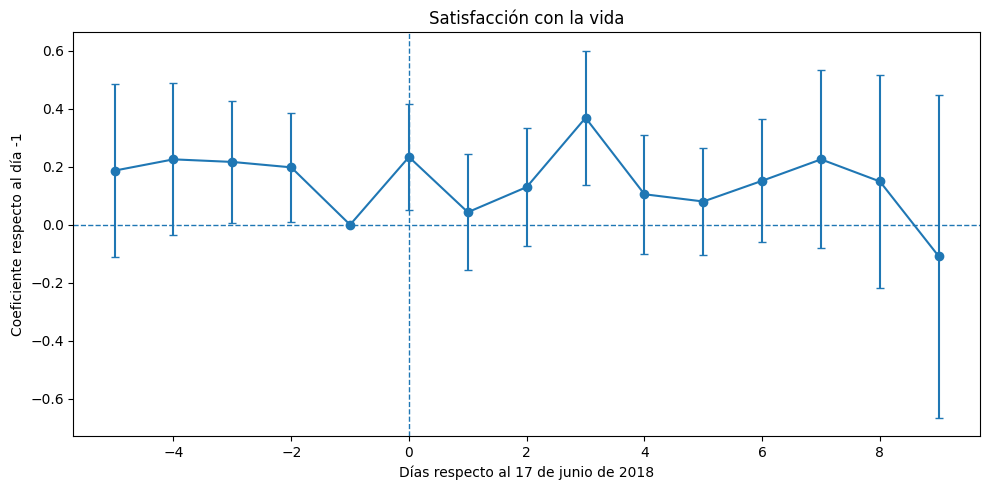

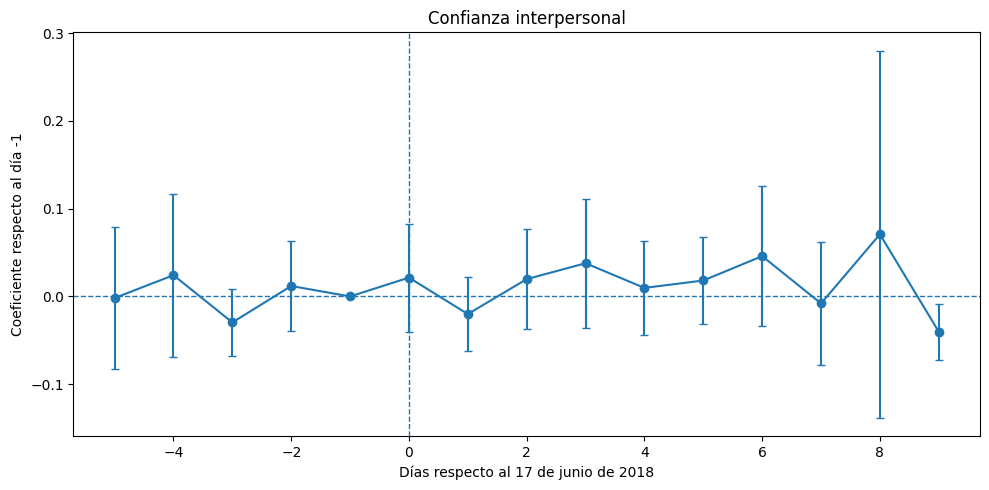

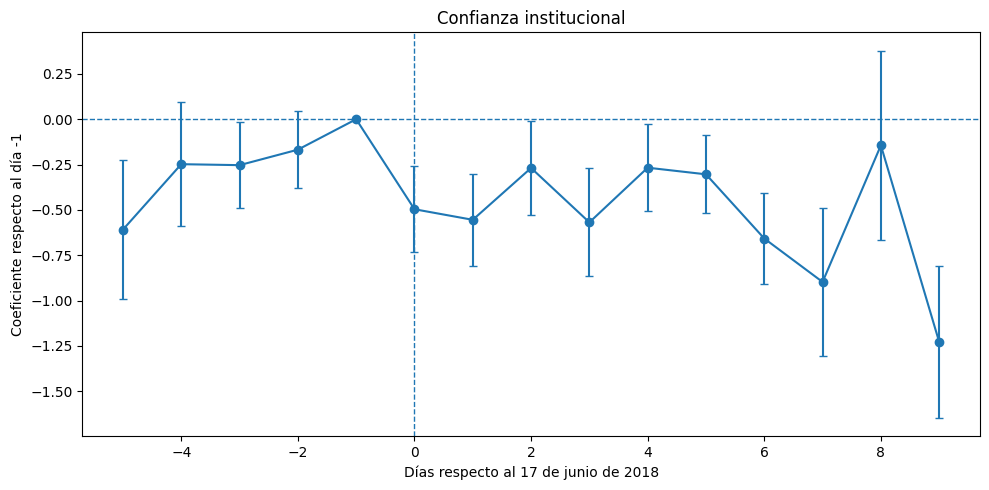

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


# ============================================================
# BRASIL 2013
# Masivas protestas populares en varias ciudades de Brasil, destacando la toma de los tejados del Congreso Nacional en Brasilia por cientos de manifestantes.
# Las marchas comenzaron en contra del aumento de las tarifas del transporte público, pero rápidamente sumaron demandas por mayor inversión estatal en salud y educación,
# así como el rechazo al multimillonario gasto público destinado a la Copa Confederaciones 2013 y al Mundial de Fútbol.
# ============================================================

es = master[
    (master['country'] == 76) &
    (master['wave'] == 2013)
].copy()

es['fecha_entrevista'] = pd.to_datetime(
    dict(
        year=es['wave'],
        month=es['mes_real'],
        day=es['dia_real']
    ),
    errors='coerce'
)

# Segunda vuelta: 17 de junio de 2013
fecha_evento = pd.Timestamp('2013-06-17')

es['dias_evento'] = (
    es['fecha_entrevista'] - fecha_evento
).dt.days

# Ventana
es = es[
    es['dias_evento'].between(-10, 10)
].copy()


# ============================================================
# FUNCIÓN EVENT STUDY
# ============================================================

def event_study(variable, titulo):

    data = es.dropna(subset=[variable]).copy()

    # Crear dummies
    X = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 = referencia
    if 'dia_-1' in X.columns:
        X = X.drop(columns='dia_-1')

    # Constante
    X = sm.add_constant(X)

    # Estimación
    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    # Extraer resultados
    resultados = []

    for dia in range(-10, 10):

        if dia == -1:
            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

    r = pd.DataFrame(resultados)

    r['ci_low'] = r['beta'] - 1.96 * r['se']
    r['ci_high'] = r['beta'] + 1.96 * r['se']

    # ========================================================
    # GRÁFICO
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.errorbar(
        r['dia'],
        r['beta'],
        yerr=1.96 * r['se'],
        fmt='o-',
        capsize=3
    )

    plt.axhline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.axvline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.xlabel(
        'Días respecto al 17 de junio de 2018'
    )

    plt.ylabel(
        'Coeficiente respecto al día -1'
    )

    plt.title(titulo)

    plt.tight_layout()
    plt.show()

    return modelo, r


# ============================================================
# TRES EVENT STUDIES
# ============================================================

modelo_felicidad, resultados_felicidad = event_study(
    'life_satisfaction_z',
    'Satisfacción con la vida'
)

modelo_interpersonal, resultados_interpersonal = event_study(
    'trust_people',
    'Confianza interpersonal'
)

modelo_institucional, resultados_institucional = event_study(
    'confianza_institucional_z',
    'Confianza institucional'
)

## Colombia 2018 (sin efecto claro)

/tmp/ipykernel_1883/1857735754.py:64: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit(


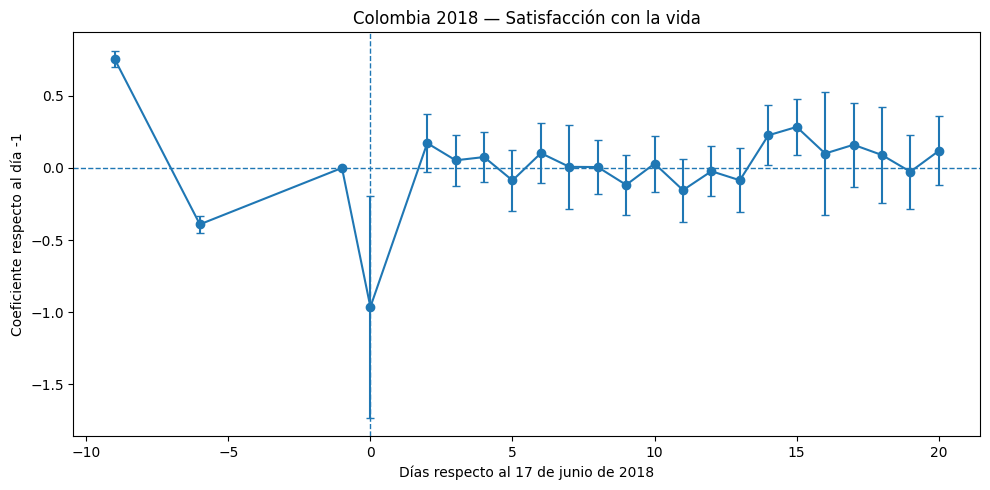

/tmp/ipykernel_1883/1857735754.py:64: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit(


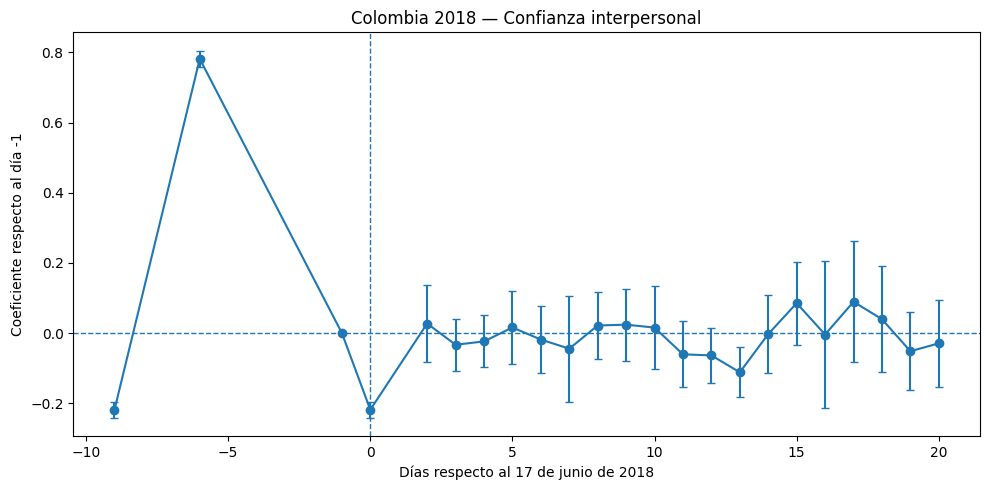

/tmp/ipykernel_1883/1857735754.py:64: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit(


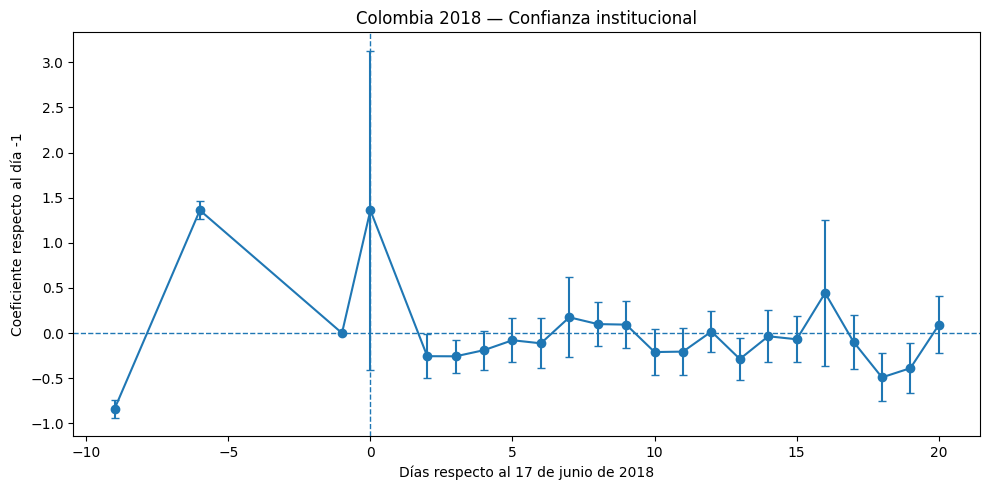

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


# ============================================================
# COLOMBIA 2018
# Se celebró la segunda vuelta de las elecciones presidenciales, un proceso electoral histórico en el que Iván Duque Márquez
# resultó elegido presidente de la República para el período 2018-2022.
# ============================================================

es = master[
    (master['country'] == 170) &
    (master['wave'] == 2018)
].copy()

es['fecha_entrevista'] = pd.to_datetime(
    dict(
        year=es['wave'],
        month=es['mes_real'],
        day=es['dia_real']
    ),
    errors='coerce'
)

# Segunda vuelta: 17 de junio de 2018
fecha_evento = pd.Timestamp('2018-06-17')

es['dias_evento'] = (
    es['fecha_entrevista'] - fecha_evento
).dt.days

# Ventana
es = es[
    es['dias_evento'].between(-10, 20)
].copy()


# ============================================================
# FUNCIÓN EVENT STUDY
# ============================================================

def event_study(variable, titulo):

    data = es.dropna(subset=[variable]).copy()

    # Crear dummies
    X = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 = referencia
    if 'dia_-1' in X.columns:
        X = X.drop(columns='dia_-1')

    # Constante
    X = sm.add_constant(X)

    # Estimación
    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    # Extraer resultados
    resultados = []

    for dia in range(-10, 21):

        if dia == -1:
            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

    r = pd.DataFrame(resultados)

    r['ci_low'] = r['beta'] - 1.96 * r['se']
    r['ci_high'] = r['beta'] + 1.96 * r['se']

    # ========================================================
    # GRÁFICO
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.errorbar(
        r['dia'],
        r['beta'],
        yerr=1.96 * r['se'],
        fmt='o-',
        capsize=3
    )

    plt.axhline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.axvline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.xlabel(
        'Días respecto al 17 de junio de 2018'
    )

    plt.ylabel(
        'Coeficiente respecto al día -1'
    )

    plt.title(titulo)

    plt.tight_layout()
    plt.show()

    return modelo, r


# ============================================================
# TRES EVENT STUDIES
# ============================================================

modelo_felicidad, resultados_felicidad = event_study(
    'life_satisfaction_z',
    'Colombia 2018 — Satisfacción con la vida'
)

modelo_interpersonal, resultados_interpersonal = event_study(
    'trust_people',
    'Colombia 2018 — Confianza interpersonal'
)

modelo_institucional, resultados_institucional = event_study(
    'confianza_institucional_z',
    'Colombia 2018 — Confianza institucional'
)

In [15]:
# ============================================================
# IMPRIMIR COEFICIENTES
# ============================================================

pd.set_option('display.max_rows', 100)

print("\n================ FELICIDAD ================\n")
print(resultados_felicidad[['dia', 'beta', 'se', 'ci_low', 'ci_high']].to_string(index=False))

print("\n================ CONFIANZA INTERPERSONAL ================\n")
print(resultados_interpersonal[['dia', 'beta', 'se', 'ci_low', 'ci_high']].to_string(index=False))

print("\n================ CONFIANZA INSTITUCIONAL ================\n")
print(resultados_institucional[['dia', 'beta', 'se', 'ci_low', 'ci_high']].to_string(index=False))


================ FELICIDAD ================

 dia      beta       se    ci_low   ci_high
  -9  0.754906 0.029561  0.696967  0.812845
  -6 -0.391097 0.029561 -0.449036 -0.333159
  -1  0.000000 0.000000  0.000000  0.000000
   0 -0.964099 0.392185 -1.732781 -0.195417
   2  0.171852 0.103717 -0.031433  0.375137
   3  0.052850 0.089763 -0.123086  0.228786
   4  0.075417 0.087767 -0.096606  0.247441
   5 -0.086690 0.108498 -0.299346  0.125965
   6  0.102566 0.106212 -0.105609  0.310741
   7  0.007513 0.148970 -0.284468  0.299493
   8  0.006184 0.094439 -0.178916  0.191284
   9 -0.117425 0.106205 -0.325587  0.090738
  10  0.029884 0.098662 -0.163493  0.223260
  11 -0.153993 0.111070 -0.371691  0.063704
  12 -0.022739 0.088687 -0.196566  0.151088
  13 -0.085496 0.112979 -0.306935  0.135942
  14  0.225981 0.106046  0.018130  0.433832
  15  0.284226 0.100315  0.087609  0.480843
  16  0.100047 0.217359 -0.325976  0.526070
  17  0.160682 0.149186 -0.131723  0.453088
  18  0.089485 0.168249 -0.240

## Perú 2016 (no muy claro efecto negativo en confianza institucional)

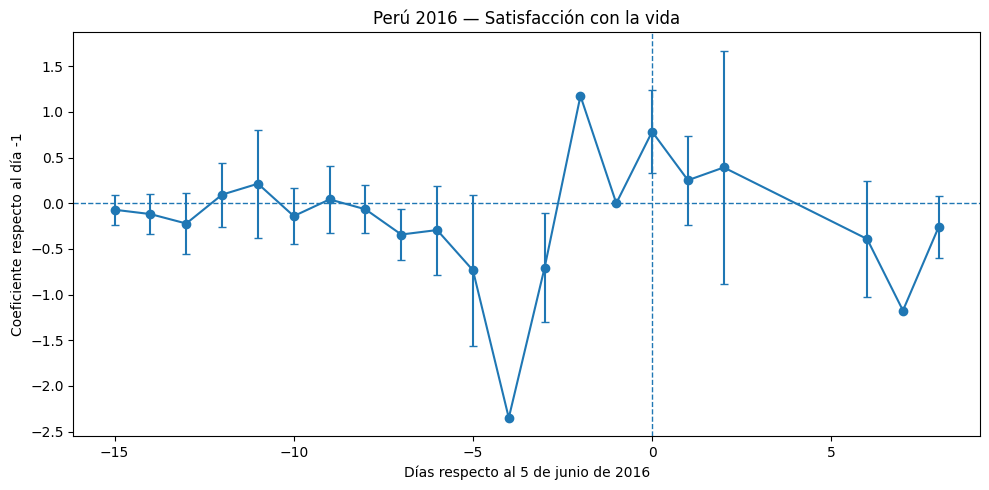

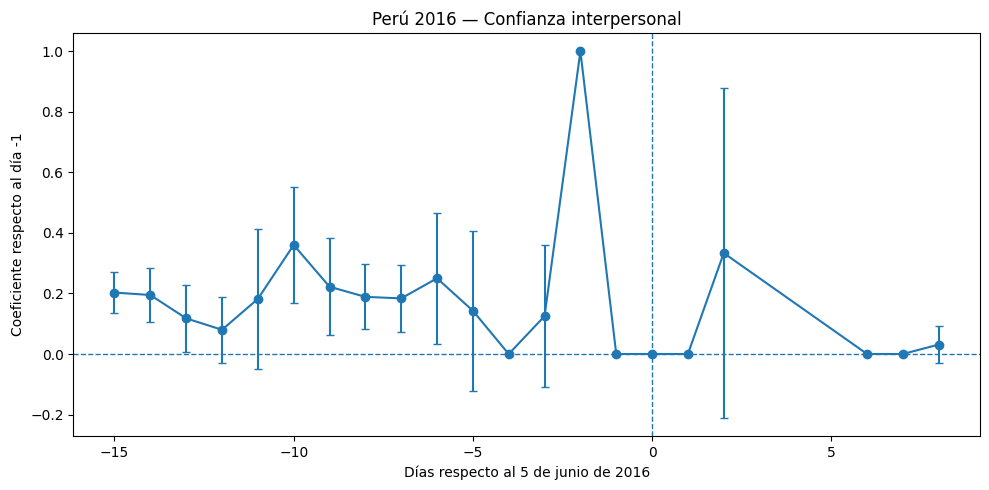

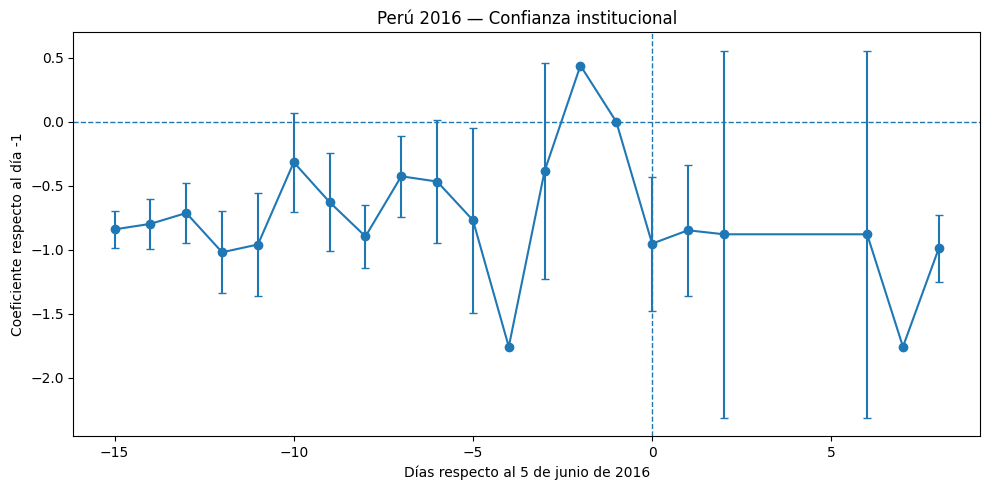


================ FELICIDAD ================

 dia      beta           se    ci_low   ci_high
 -15 -0.071454 8.352535e-02 -0.235164  0.092255
 -14 -0.118990 1.106086e-01 -0.335783  0.097803
 -13 -0.222303 1.703527e-01 -0.556194  0.111589
 -12  0.094002 1.782911e-01 -0.255448  0.443453
 -11  0.213641 3.009901e-01 -0.376299  0.803582
 -10 -0.141003 1.563265e-01 -0.447403  0.165397
  -9  0.041965 1.863425e-01 -0.323266  0.407197
  -8 -0.066511 1.334147e-01 -0.328004  0.194982
  -7 -0.342716 1.410163e-01 -0.619108 -0.066325
  -6 -0.293757 2.483579e-01 -0.780538  0.193025
  -5 -0.734392 4.202783e-01 -1.558138  0.089353
  -4 -2.350056 1.259329e-14 -2.350056 -2.350056
  -3 -0.705017 3.031040e-01 -1.299101 -0.110933
  -2  1.175028 1.282441e-14  1.175028  1.175028
  -1  0.000000 0.000000e+00  0.000000  0.000000
   0  0.783352 2.305790e-01  0.331417  1.235287
   1  0.251792 2.474016e-01 -0.233115  0.736699
   2  0.391676 6.521759e-01 -0.886589  1.669941
   6 -0.391676 3.260880e-01 -1.030808  0.2

In [16]:
# ============================================================
# PERÚ 2016
# ============================================================

es = master[
    (master['country'] == 604) &
    (master['wave'] == 2016)
].copy()

es['fecha_entrevista'] = pd.to_datetime(
    dict(
        year=es['wave'],
        month=es['mes_real'],
        day=es['dia_real']
    ),
    errors='coerce'
)

# Segunda vuelta presidencial: 5 de junio de 2016
fecha_evento = pd.Timestamp('2016-06-05')

es['dias_evento'] = (
    es['fecha_entrevista'] - fecha_evento
).dt.days

# Ventana: -15 a +8
es = es[
    es['dias_evento'].between(-15, 8)
].copy()


# ============================================================
# FUNCIÓN EVENT STUDY
# ============================================================

def event_study(variable, titulo):

    data = es.dropna(subset=[variable]).copy()

    X = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 = referencia
    if 'dia_-1' in X.columns:
        X = X.drop(columns='dia_-1')

    X = sm.add_constant(X)

    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    resultados = []

    for dia in range(-15, 9):

        if dia == -1:
            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

    r = pd.DataFrame(resultados)

    r['ci_low'] = r['beta'] - 1.96 * r['se']
    r['ci_high'] = r['beta'] + 1.96 * r['se']

    # ========================================================
    # GRÁFICO
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.errorbar(
        r['dia'],
        r['beta'],
        yerr=1.96 * r['se'],
        fmt='o-',
        capsize=3
    )

    plt.axhline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.axvline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.xlabel(
        'Días respecto al 5 de junio de 2016'
    )

    plt.ylabel(
        'Coeficiente respecto al día -1'
    )

    plt.title(titulo)

    plt.tight_layout()
    plt.show()

    return modelo, r


# ============================================================
# TRES EVENT STUDIES
# ============================================================

modelo_felicidad, resultados_felicidad = event_study(
    'life_satisfaction_z',
    'Perú 2016 — Satisfacción con la vida'
)

modelo_interpersonal, resultados_interpersonal = event_study(
    'trust_people',
    'Perú 2016 — Confianza interpersonal'
)

modelo_institucional, resultados_institucional = event_study(
    'confianza_institucional_z',
    'Perú 2016 — Confianza institucional'
)


# ============================================================
# IMPRIMIR COEFICIENTES
# ============================================================

pd.set_option('display.max_rows', 100)

print("\n================ FELICIDAD ================\n")
print(resultados_felicidad[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

print("\n================ CONFIANZA INTERPERSONAL ================\n")
print(resultados_interpersonal[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

print("\n================ CONFIANZA INSTITUCIONAL ================\n")
print(resultados_institucional[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

## Venezuela 2004 (efecto negativo no muy claro en confianza interpersonal)

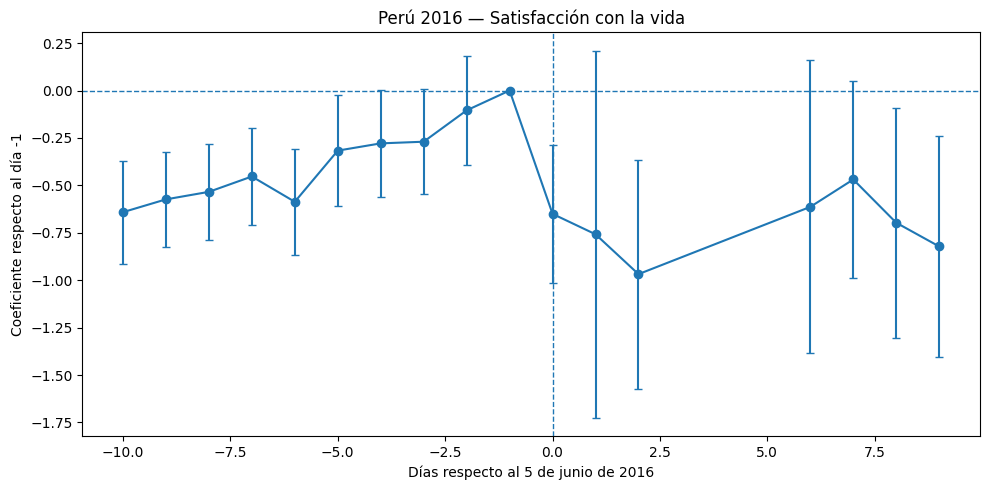

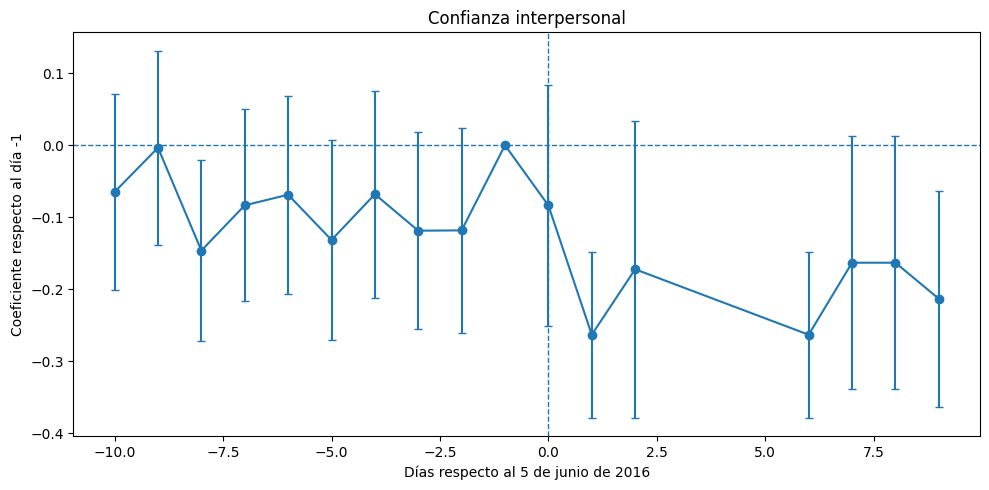

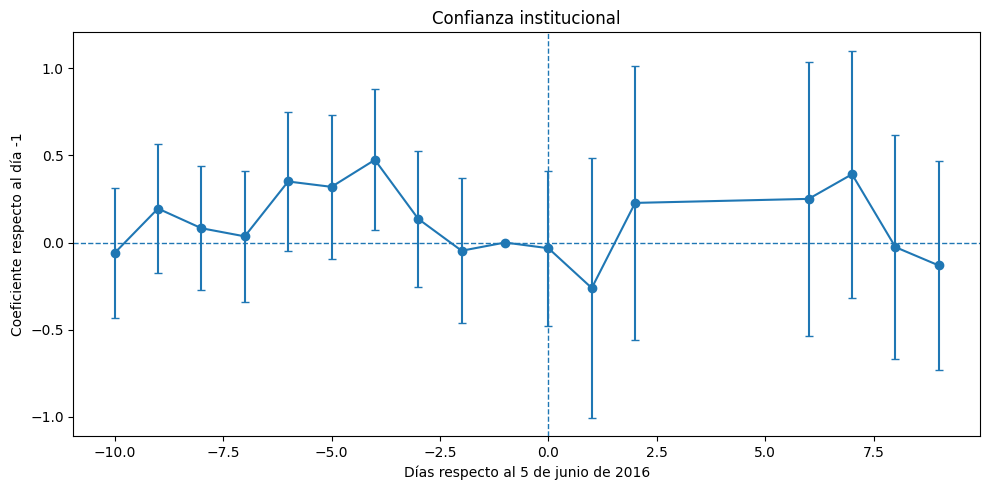


================ FELICIDAD ================

 dia      beta       se    ci_low   ci_high
 -10 -0.641437 0.138730 -0.913347 -0.369526
  -9 -0.573934 0.128449 -0.825694 -0.322174
  -8 -0.534270 0.129857 -0.788790 -0.279750
  -7 -0.453333 0.130943 -0.709982 -0.196684
  -6 -0.586751 0.143253 -0.867527 -0.305975
  -5 -0.316915 0.148549 -0.608071 -0.025759
  -4 -0.278705 0.143797 -0.560548  0.003138
  -3 -0.269934 0.140625 -0.545558  0.005691
  -2 -0.104637 0.147103 -0.392960  0.183685
  -1  0.000000 0.000000  0.000000  0.000000
   0 -0.650473 0.184592 -1.012273 -0.288673
   1 -0.758004 0.493876 -1.726000  0.209993
   2 -0.968178 0.308266 -1.572379 -0.363976
   6 -0.613509 0.393893 -1.385540  0.158521
   7 -0.469015 0.263831 -0.986124  0.048095
   8 -0.697164 0.309267 -1.303328 -0.091000
   9 -0.822224 0.297880 -1.406068 -0.238379

================ CONFIANZA INTERPERSONAL ================

 dia      beta       se    ci_low   ci_high
 -10 -0.064882 0.069618 -0.201333  0.071569
  -9 -0.003418

In [17]:
# ============================================================
# VENEZUELA 2004
# El Consejo Nacional Electoral (CNE) de Venezuela anunció oficialmente que la oposición había recolectado las firmas suficientes para activar el referéndum revocatorio
# contra el presidente Hugo Chávez. El clima político del país escaló fuertemente en tensiones.
# ============================================================

es = master[
    (master['country'] == 862) &
    (master['wave'] == 2004)
].copy()

es['fecha_entrevista'] = pd.to_datetime(
    dict(
        year=es['wave'],
        month=es['mes_real'],
        day=es['dia_real']
    ),
    errors='coerce'
)

# Anuncio/Confirmación del Referéndum Revocatorio: 3 de junio de 2004
fecha_evento = pd.Timestamp('2004-06-03')

es['dias_evento'] = (
    es['fecha_entrevista'] - fecha_evento
).dt.days

# Ventana
es = es[
    es['dias_evento'].between(-10, 10)
].copy()


# ============================================================
# FUNCIÓN EVENT STUDY
# ============================================================

def event_study(variable, titulo):

    data = es.dropna(subset=[variable]).copy()

    X = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 = referencia
    if 'dia_-1' in X.columns:
        X = X.drop(columns='dia_-1')

    X = sm.add_constant(X)

    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    resultados = []

    for dia in range(-10, 10):

        if dia == -1:
            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

    r = pd.DataFrame(resultados)

    r['ci_low'] = r['beta'] - 1.96 * r['se']
    r['ci_high'] = r['beta'] + 1.96 * r['se']

    # ========================================================
    # GRÁFICO
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.errorbar(
        r['dia'],
        r['beta'],
        yerr=1.96 * r['se'],
        fmt='o-',
        capsize=3
    )

    plt.axhline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.axvline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.xlabel(
        'Días respecto al 5 de junio de 2016'
    )

    plt.ylabel(
        'Coeficiente respecto al día -1'
    )

    plt.title(titulo)

    plt.tight_layout()
    plt.show()

    return modelo, r


# ============================================================
# TRES EVENT STUDIES
# ============================================================


modelo_felicidad, resultados_felicidad = event_study(
    'life_satisfaction_z',
    'Perú 2016 — Satisfacción con la vida'
)

modelo_interpersonal, resultados_interpersonal = event_study(
    'trust_people',
    'Confianza interpersonal'
)

modelo_institucional, resultados_institucional = event_study(
    'confianza_institucional_z',
    'Confianza institucional'
)


# ============================================================
# IMPRIMIR COEFICIENTES
# ============================================================

pd.set_option('display.max_rows', 100)

print("\n================ FELICIDAD ================\n")
print(resultados_felicidad[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

print("\n================ CONFIANZA INTERPERSONAL ================\n")
print(resultados_interpersonal[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

print("\n================ CONFIANZA INSTITUCIONAL ================\n")
print(resultados_institucional[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

## Pooled

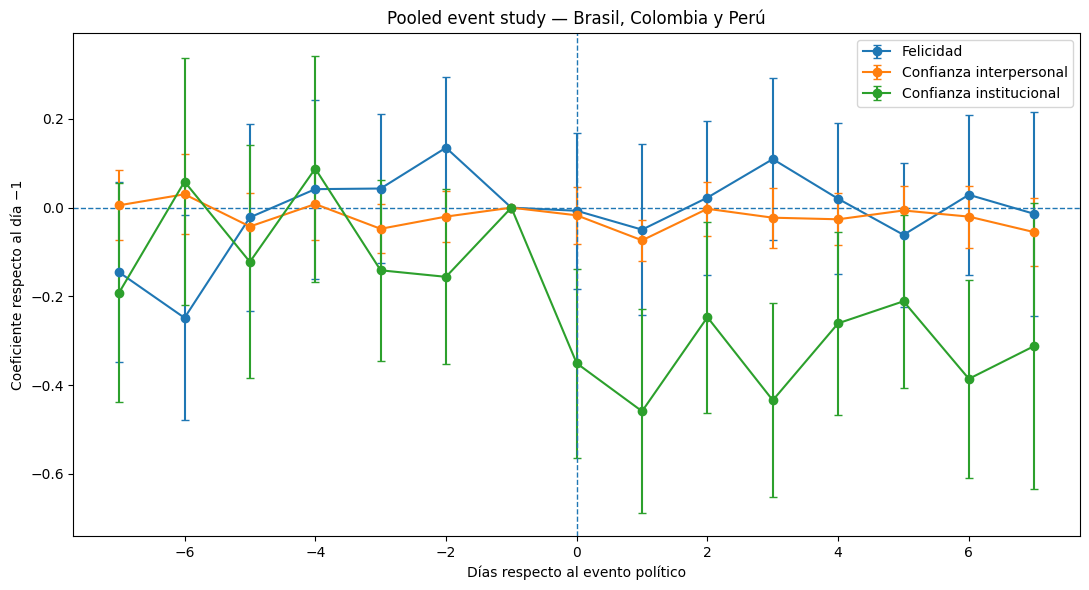

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


# ============================================================
# 1. CONSTRUIR EL POOLED
# ============================================================

casos = [
    {'country': 76,  'wave': 2013, 'evento': '2013-06-17', 'nombre': 'Brasil'},
    {'country': 170, 'wave': 2018, 'evento': '2018-06-17', 'nombre': 'Colombia'},
    {'country': 604, 'wave': 2016, 'evento': '2016-06-05', 'nombre': 'Perú'},
    {'country': 862, 'wave': 2004, 'evento': '2004-06-03', 'nombre': 'Venezuela'}
]

dfs = []

for caso in casos:

    d = master[
        (master['country'] == caso['country']) &
        (master['wave'] == caso['wave'])
    ].copy()

    d['fecha_entrevista'] = pd.to_datetime(
        dict(
            year=d['wave'],
            month=d['mes_real'],
            day=d['dia_real']
        ),
        errors='coerce'
    )

    fecha_evento = pd.Timestamp(caso['evento'])

    d['dias_evento'] = (
        d['fecha_entrevista'] - fecha_evento
    ).dt.days

    d['pais_evento'] = caso['nombre']

    # Ventana común
    d = d[d['dias_evento'].between(-7, 7)].copy()

    dfs.append(d)

es_pool = pd.concat(dfs, ignore_index=True)


# ============================================================
# 2. EVENT STUDY POOLED CON EFECTOS FIJOS DE PAÍS
# ============================================================

def pooled_event_study(variable):

    data = es_pool.dropna(subset=[variable]).copy()

    # --------------------------------------------
    # Dummies de distancia al evento
    # --------------------------------------------

    X_evento = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 = referencia
    if 'dia_-1' in X_evento.columns:
        X_evento = X_evento.drop(columns='dia_-1')

    # --------------------------------------------
    # Efectos fijos de país/evento
    # --------------------------------------------

    X_pais = pd.get_dummies(
        data['pais_evento'],
        prefix='pais',
        drop_first=True,
        dtype=float
    )

    # --------------------------------------------
    # Matriz final
    # --------------------------------------------

    X = pd.concat(
        [X_evento, X_pais],
        axis=1
    )

    X = sm.add_constant(X)

    # --------------------------------------------
    # OLS
    # --------------------------------------------

    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    # --------------------------------------------
    # Extraer coeficientes
    # --------------------------------------------

    resultados = []

    for dia in range(-7, 8):

        if dia == -1:

            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

    r = pd.DataFrame(resultados)

    r['ci_low'] = (
        r['beta'] - 1.96 * r['se']
    )

    r['ci_high'] = (
        r['beta'] + 1.96 * r['se']
    )

    return modelo, r


# ============================================================
# 3. ESTIMAR LAS TRES VARIABLES
# ============================================================

modelo_fel, r_fel = pooled_event_study(
    'life_satisfaction_z'
)

modelo_inter, r_inter = pooled_event_study(
    'trust_people'
)

modelo_inst, r_inst = pooled_event_study(
    'confianza_institucional_z'
)


# ============================================================
# 4. GRÁFICO
# ============================================================

plt.figure(figsize=(11, 6))

plt.errorbar(
    r_fel['dia'],
    r_fel['beta'],
    yerr=1.96 * r_fel['se'],
    fmt='o-',
    capsize=3,
    label='Felicidad'
)

plt.errorbar(
    r_inter['dia'],
    r_inter['beta'],
    yerr=1.96 * r_inter['se'],
    fmt='o-',
    capsize=3,
    label='Confianza interpersonal'
)

plt.errorbar(
    r_inst['dia'],
    r_inst['beta'],
    yerr=1.96 * r_inst['se'],
    fmt='o-',
    capsize=3,
    label='Confianza institucional'
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Días respecto al evento político')
plt.ylabel('Coeficiente respecto al día −1')

plt.title(
    'Pooled event study — Brasil, Colombia y Perú'
)

plt.legend()
plt.tight_layout()
plt.show()

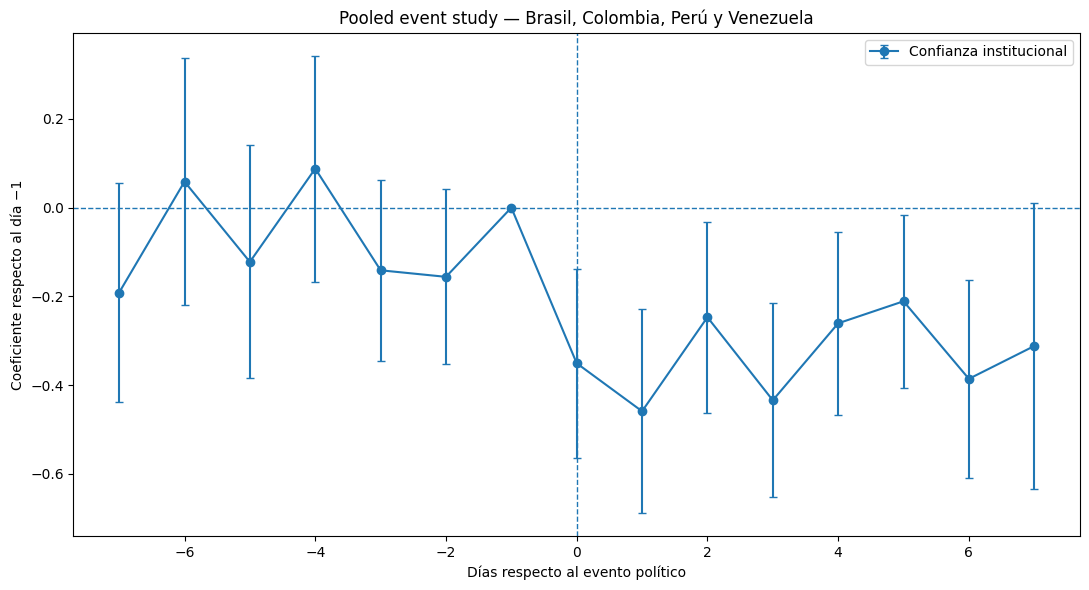

In [29]:
# ============================================================
# 4.1 SOLO CONFIANZA INSTITUCIONAL
# ============================================================

plt.figure(figsize=(11, 6))


plt.errorbar(
    r_inst['dia'],
    r_inst['beta'],
    yerr=1.96 * r_inst['se'],
    fmt='o-',
    capsize=3,
    label='Confianza institucional'
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Días respecto al evento político')
plt.ylabel('Coeficiente respecto al día −1')

plt.title(
    'Pooled event study — Brasil, Colombia, Perú y Venezuela'
)

plt.legend()
plt.tight_layout()
plt.show()

# Event Studies - Shock en Interés en Política

## Colombia 2018 (pareciera mejorar confianza institucional)

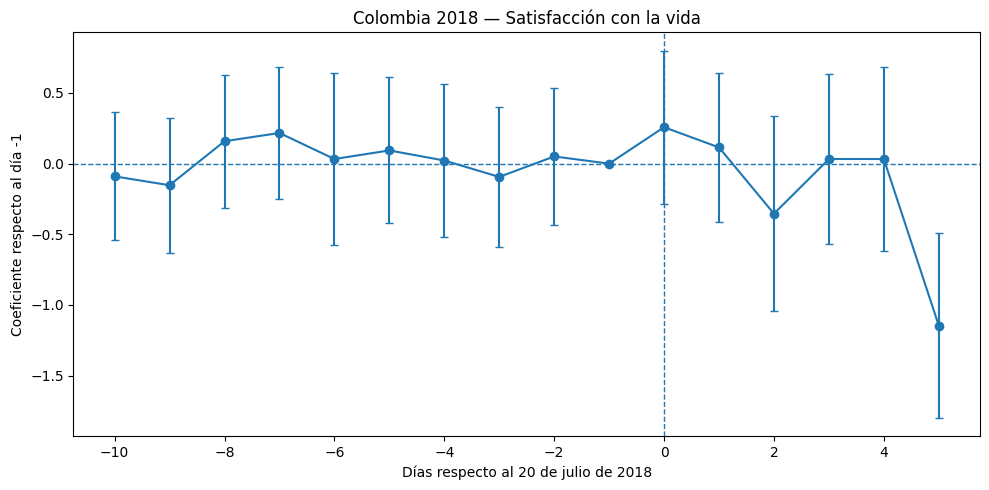

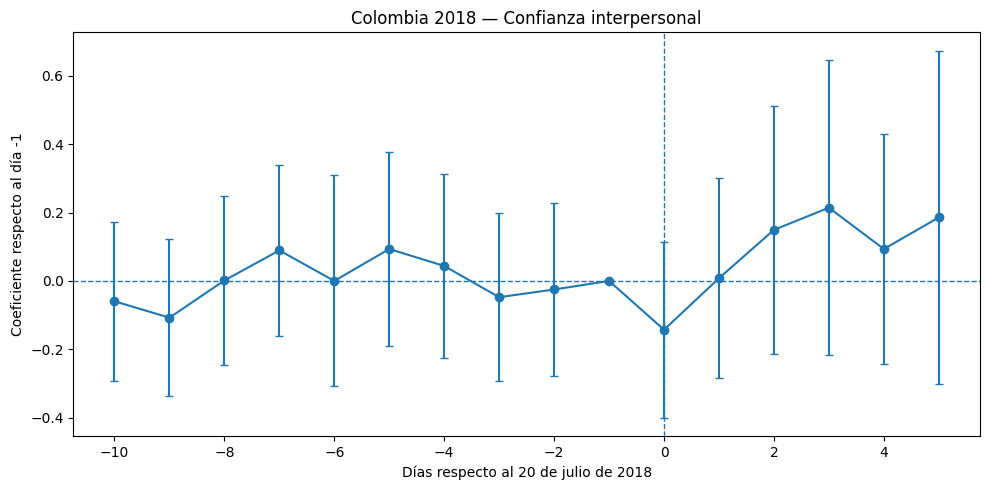

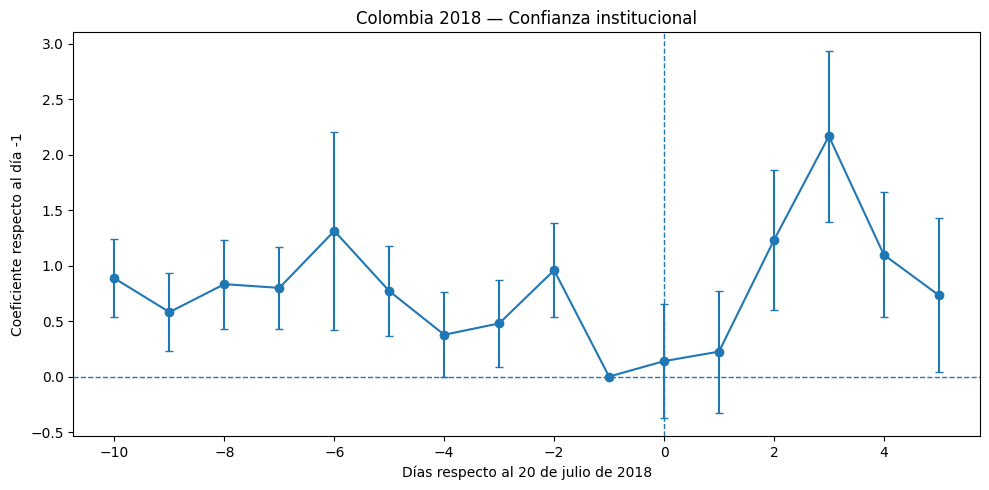


================ FELICIDAD ================

 dia      beta       se    ci_low   ci_high
 -10 -0.090043 0.231437 -0.543660  0.363574
  -9 -0.152800 0.242886 -0.628858  0.323257
  -8  0.158677 0.239396 -0.310539  0.627894
  -7  0.216922 0.236642 -0.246896  0.680740
  -6  0.032743 0.311797 -0.578379  0.643865
  -5  0.093378 0.263660 -0.423396  0.610152
  -4  0.022181 0.276088 -0.518952  0.563314
  -3 -0.093764 0.252406 -0.588480  0.400952
  -2  0.050933 0.247779 -0.434713  0.536580
  -1  0.000000 0.000000  0.000000  0.000000
   0  0.257851 0.276182 -0.283465  0.799167
   1  0.114600 0.270226 -0.415043  0.644244
   2 -0.354219 0.351080 -1.042336  0.333897
   3  0.032743 0.305390 -0.565822  0.631308
   4  0.032743 0.333252 -0.620432  0.685918
   5 -1.146003 0.333039 -1.798759 -0.493247

================ CONFIANZA INTERPERSONAL ================

 dia          beta       se    ci_low  ci_high
 -10 -5.952381e-02 0.118467 -0.291719 0.172671
  -9 -1.076190e-01 0.117210 -0.337350 0.122112
  -8 

In [31]:
# ============================================================
# COLOMBIA 2018
# ESTATUTO DE LA OPOSICIÓN
#
# La idea de esto es ver un shock positivo en el interés en política. No hay datos de interés en política, pero se ve un efecto positivo en confianza institucional.
# Promulgación de la Ley 1908 de 2018 por parte del Congreso de la República, diseñada específicamente para fortalecer la investigación y judicialización de organizaciones criminales .
# ============================================================

es = master[
    (master['country'] == 170) &
    (master['wave'] == 2018)
].copy()

es['fecha_entrevista'] = pd.to_datetime(
    dict(
        year=es['wave'],
        month=es['mes_real'],
        day=es['dia_real']
    ),
    errors='coerce'
)

# Estatuto de la Oposición : 9 de julio de 2018
fecha_evento = pd.Timestamp('2018-07-09')

es['dias_evento'] = (
    es['fecha_entrevista'] - fecha_evento
).dt.days

# Ventana: -15 a +15
es = es[
    es['dias_evento'].between(-10, 10)
].copy()


# ============================================================
# FUNCIÓN EVENT STUDY
# ============================================================

def event_study(variable, titulo):

    data = es.dropna(subset=[variable]).copy()

    X = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 = referencia
    if 'dia_-1' in X.columns:
        X = X.drop(columns='dia_-1')

    X = sm.add_constant(X)

    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    resultados = []

    for dia in range(-10, 10):

        if dia == -1:
            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

    r = pd.DataFrame(resultados)

    r['ci_low'] = r['beta'] - 1.96 * r['se']
    r['ci_high'] = r['beta'] + 1.96 * r['se']

    # ========================================================
    # GRÁFICO
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.errorbar(
        r['dia'],
        r['beta'],
        yerr=1.96 * r['se'],
        fmt='o-',
        capsize=3
    )

    plt.axhline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.axvline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.xlabel(
        'Días respecto al 20 de julio de 2018'
    )

    plt.ylabel(
        'Coeficiente respecto al día -1'
    )

    plt.title(titulo)

    plt.tight_layout()
    plt.show()

    return modelo, r


# ============================================================
# TRES EVENT STUDIES
# ============================================================

modelo_felicidad, resultados_felicidad = event_study(
    'life_satisfaction_z',
    'Colombia 2018 — Satisfacción con la vida'
)

modelo_interpersonal, resultados_interpersonal = event_study(
    'trust_people',
    'Colombia 2018 — Confianza interpersonal'
)

modelo_institucional, resultados_institucional = event_study(
    'confianza_institucional_z',
    'Colombia 2018 — Confianza institucional'
)

### NO HAY DATOS DE INTERÉS EN POLÍTICA

# ============================================================
# IMPRIMIR COEFICIENTES
# ============================================================

pd.set_option('display.max_rows', 100)

print("\n================ FELICIDAD ================\n")
print(resultados_felicidad[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

print("\n================ CONFIANZA INTERPERSONAL ================\n")
print(resultados_interpersonal[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

print("\n================ CONFIANZA INSTITUCIONAL ================\n")
print(resultados_institucional[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))



## Ecuador 2008 (pareciera mejorar confianza institucional)

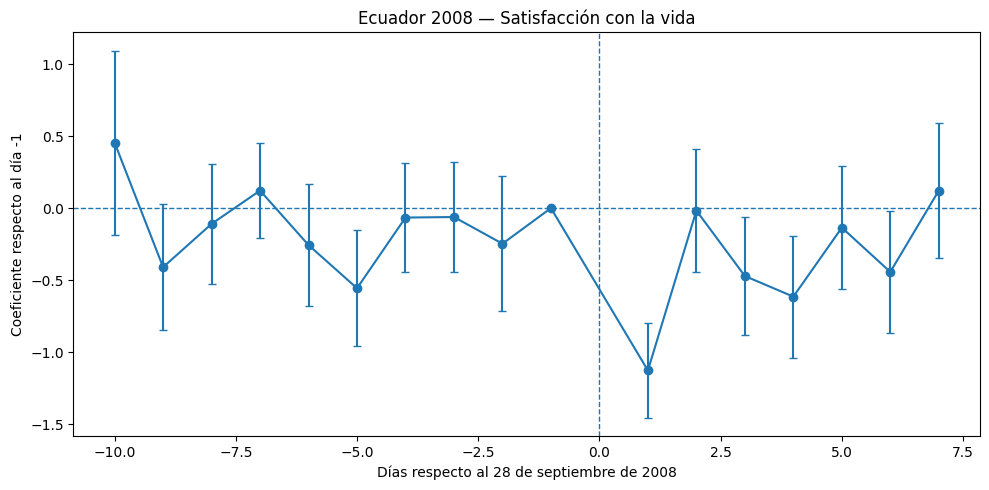

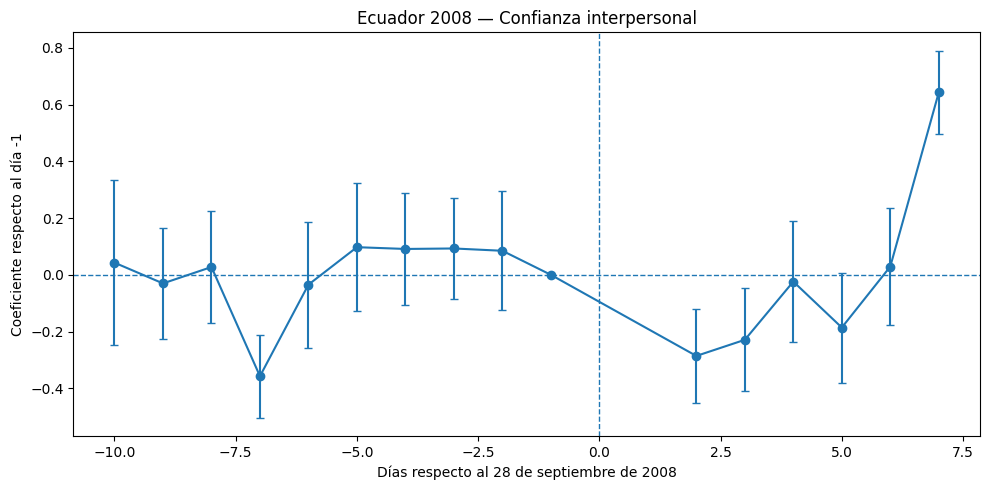

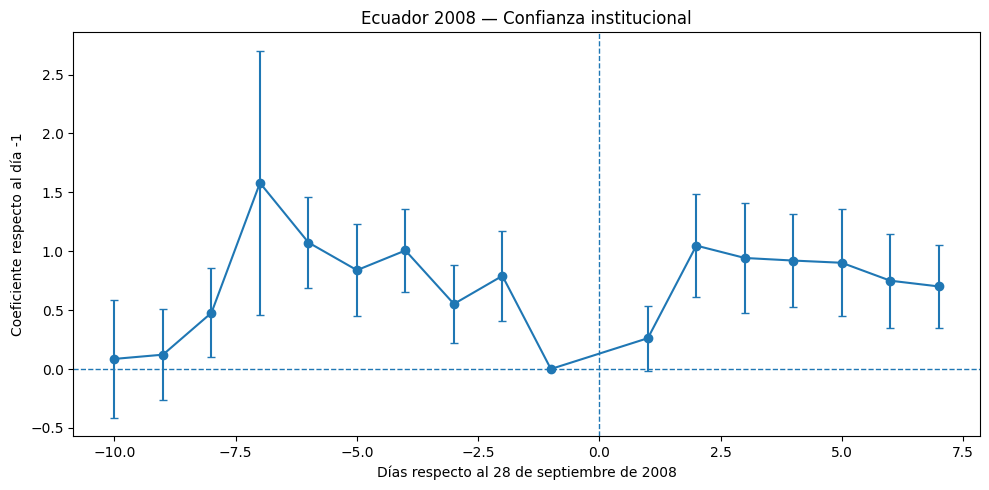


================ FELICIDAD ================

 dia      beta       se    ci_low   ci_high
 -10  0.454664 0.325434 -0.183186  1.092514
  -9 -0.409897 0.222896 -0.846773  0.026979
  -8 -0.109381 0.211459 -0.523841  0.305079
  -7  0.121785 0.167859 -0.207218  0.450788
  -6 -0.256487 0.217320 -0.682433  0.169460
  -5 -0.555862 0.205256 -0.958164 -0.153559
  -4 -0.065459 0.194413 -0.446510  0.315591
  -3 -0.061788 0.193711 -0.441461  0.317885
  -2 -0.247030 0.239222 -0.715904  0.221845
  -1  0.000000 0.000000  0.000000  0.000000
   1 -1.126511 0.167859 -1.455515 -0.797508
   2 -0.016915 0.217913 -0.444025  0.410196
   3 -0.471156 0.210114 -0.882979 -0.059332
   4 -0.614390 0.215671 -1.037105 -0.191675
   5 -0.135217 0.216654 -0.559858  0.289424
   6 -0.442921 0.216056 -0.866390 -0.019451
   7  0.121785 0.237938 -0.344574  0.588144

================ CONFIANZA INTERPERSONAL ================

 dia      beta       se    ci_low   ci_high
 -10  0.042857 0.148381 -0.247969  0.333684
  -9 -0.030220

In [21]:
# ============================================================
# ECUADOR 2008
# REFERÉNDUM CONSTITUCIONAL
#
# 28 de septiembre de 2008
#
# Se celebró el Referéndum Constitucional. La ciudadanía aprobó la actual Constitución de la República del Ecuador con más del 63% de los votos a favor.
# ============================================================

es = master[
    (master['country'] == 218) &
    (master['wave'] == 2008)
].copy()

es['fecha_entrevista'] = pd.to_datetime(
    dict(
        year=es['wave'],
        month=es['mes_real'],
        day=es['dia_real']
    ),
    errors='coerce'
)

# Referéndum constitucional: 28 de septiembre de 2008
fecha_evento = pd.Timestamp('2008-09-28')

es['dias_evento'] = (
    es['fecha_entrevista'] - fecha_evento
).dt.days

# Ventana: -10 a +10
es = es[
    es['dias_evento'].between(-10, 10)
].copy()


# ============================================================
# FUNCIÓN EVENT STUDY
# ============================================================

def event_study(variable, titulo):

    data = es.dropna(subset=[variable]).copy()

    X = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 = referencia
    if 'dia_-1' in X.columns:
        X = X.drop(columns='dia_-1')

    X = sm.add_constant(X)

    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    resultados = []

    for dia in range(-10, 11):

        if dia == -1:

            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

    r = pd.DataFrame(resultados)

    r['ci_low'] = r['beta'] - 1.96 * r['se']
    r['ci_high'] = r['beta'] + 1.96 * r['se']

    # ========================================================
    # GRÁFICO
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.errorbar(
        r['dia'],
        r['beta'],
        yerr=1.96 * r['se'],
        fmt='o-',
        capsize=3
    )

    plt.axhline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.axvline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.xlabel(
        'Días respecto al 28 de septiembre de 2008'
    )

    plt.ylabel(
        'Coeficiente respecto al día -1'
    )

    plt.title(titulo)

    plt.tight_layout()
    plt.show()

    return modelo, r


# ============================================================
# CUATRO EVENT STUDIES
# ============================================================

modelo_felicidad, resultados_felicidad = event_study(
    'life_satisfaction_z',
    'Ecuador 2008 — Satisfacción con la vida'
)

modelo_interpersonal, resultados_interpersonal = event_study(
    'trust_people',
    'Ecuador 2008 — Confianza interpersonal'
)

modelo_institucional, resultados_institucional = event_study(
    'confianza_institucional_z',
    'Ecuador 2008 — Confianza institucional'
)

## NO tengo datos para interés en política

# ============================================================
# IMPRIMIR COEFICIENTES
# ============================================================

pd.set_option('display.max_rows', 100)

print("\n================ FELICIDAD ================\n")
print(resultados_felicidad[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

print("\n================ CONFIANZA INTERPERSONAL ================\n")
print(resultados_interpersonal[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

print("\n================ CONFIANZA INSTITUCIONAL ================\n")
print(resultados_institucional[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))



## Pooled

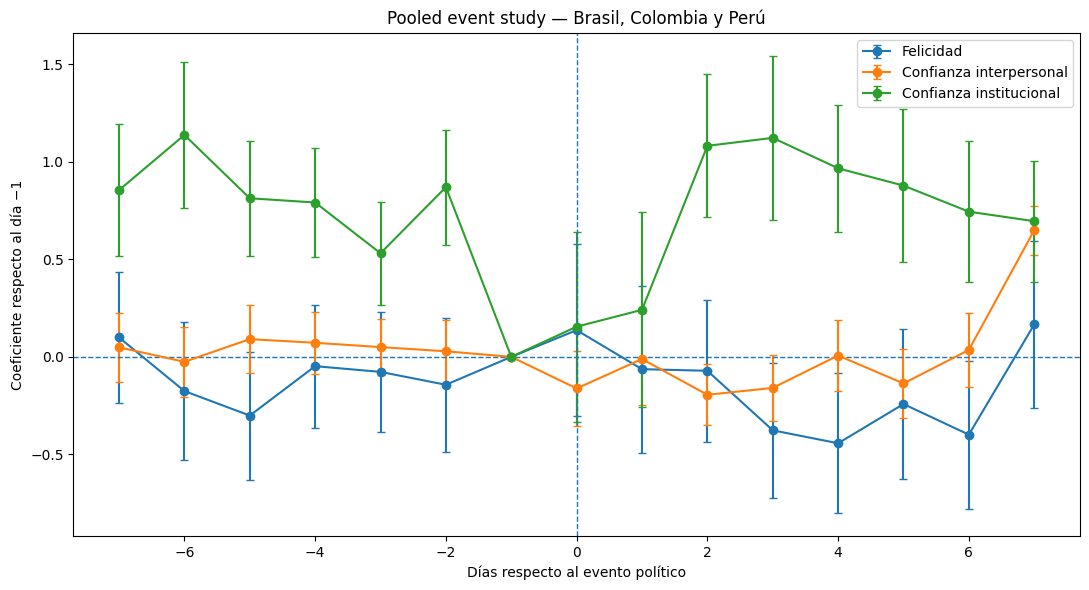

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


# ============================================================
# 1. CONSTRUIR EL POOLED
# ============================================================

casos = [
    {'country': 170,  'wave': 2018, 'evento': '2018-07-9', 'nombre': 'Colombia'},
    {'country': 218, 'wave': 2008, 'evento': '2008-09-28', 'nombre': 'Ecuador'}

]

dfs = []

for caso in casos:

    d = master[
        (master['country'] == caso['country']) &
        (master['wave'] == caso['wave'])
    ].copy()

    d['fecha_entrevista'] = pd.to_datetime(
        dict(
            year=d['wave'],
            month=d['mes_real'],
            day=d['dia_real']
        ),
        errors='coerce'
    )

    fecha_evento = pd.Timestamp(caso['evento'])

    d['dias_evento'] = (
        d['fecha_entrevista'] - fecha_evento
    ).dt.days

    d['pais_evento'] = caso['nombre']

    # Ventana común
    d = d[d['dias_evento'].between(-7, 7)].copy()

    dfs.append(d)

es_pool = pd.concat(dfs, ignore_index=True)


# ============================================================
# 2. EVENT STUDY POOLED CON EFECTOS FIJOS DE PAÍS
# ============================================================

def pooled_event_study(variable):

    data = es_pool.dropna(subset=[variable]).copy()

    # --------------------------------------------
    # Dummies de distancia al evento
    # --------------------------------------------

    X_evento = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 = referencia
    if 'dia_-1' in X_evento.columns:
        X_evento = X_evento.drop(columns='dia_-1')

    # --------------------------------------------
    # Efectos fijos de país/evento
    # --------------------------------------------

    X_pais = pd.get_dummies(
        data['pais_evento'],
        prefix='pais',
        drop_first=True,
        dtype=float
    )

    # --------------------------------------------
    # Matriz final
    # --------------------------------------------

    X = pd.concat(
        [X_evento, X_pais],
        axis=1
    )

    X = sm.add_constant(X)

    # --------------------------------------------
    # OLS
    # --------------------------------------------

    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    # --------------------------------------------
    # Extraer coeficientes
    # --------------------------------------------

    resultados = []

    for dia in range(-7, 8):

        if dia == -1:

            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

    r = pd.DataFrame(resultados)

    r['ci_low'] = (
        r['beta'] - 1.96 * r['se']
    )

    r['ci_high'] = (
        r['beta'] + 1.96 * r['se']
    )

    return modelo, r


# ============================================================
# 3. ESTIMAR LAS TRES VARIABLES
# ============================================================

modelo_fel, r_fel = pooled_event_study(
    'life_satisfaction_z'
)

modelo_inter, r_inter = pooled_event_study(
    'trust_people'
)

modelo_inst, r_inst = pooled_event_study(
    'confianza_institucional_z'
)


# ============================================================
# 4. GRÁFICO
# ============================================================

plt.figure(figsize=(11, 6))

plt.errorbar(
    r_fel['dia'],
    r_fel['beta'],
    yerr=1.96 * r_fel['se'],
    fmt='o-',
    capsize=3,
    label='Felicidad'
)

plt.errorbar(
    r_inter['dia'],
    r_inter['beta'],
    yerr=1.96 * r_inter['se'],
    fmt='o-',
    capsize=3,
    label='Confianza interpersonal'
)

plt.errorbar(
    r_inst['dia'],
    r_inst['beta'],
    yerr=1.96 * r_inst['se'],
    fmt='o-',
    capsize=3,
    label='Confianza institucional'
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Días respecto al evento político')
plt.ylabel('Coeficiente respecto al día −1')

plt.title(
    'Pooled event study — Colombia y Ecuador'
)

plt.legend()
plt.tight_layout()
plt.show()

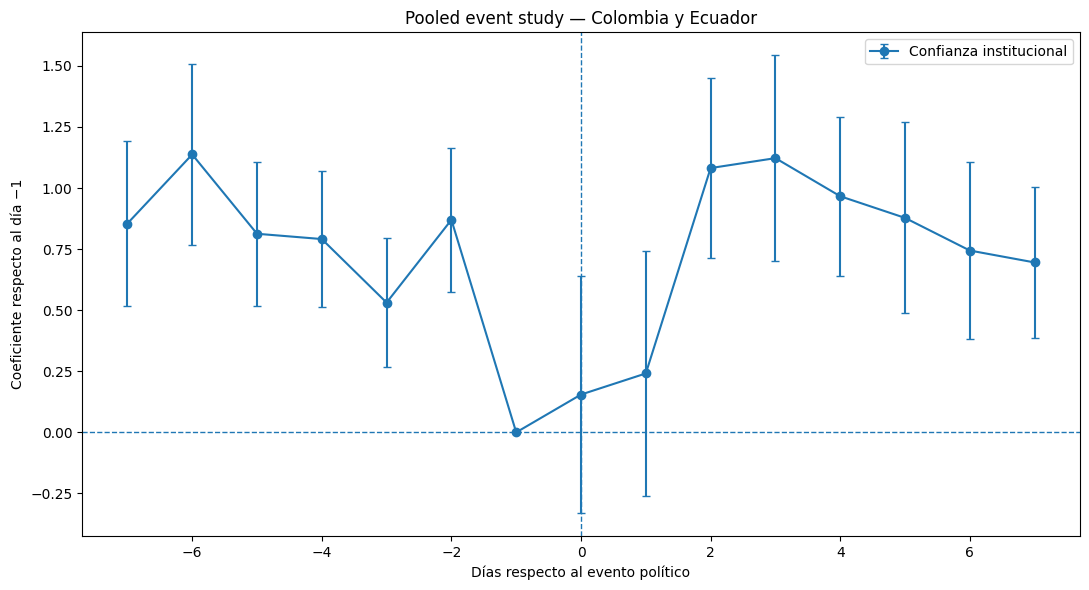

In [33]:

# ============================================================
# 4. SOLO CONFIANZA INSTITUCIONAL
# ============================================================

plt.figure(figsize=(11, 6))

plt.errorbar(
    r_inst['dia'],
    r_inst['beta'],
    yerr=1.96 * r_inst['se'],
    fmt='o-',
    capsize=3,
    label='Confianza institucional'
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Días respecto al evento político')
plt.ylabel('Coeficiente respecto al día −1')

plt.title(
    'Pooled event study — Colombia y Ecuador'
)

plt.legend()
plt.tight_layout()
plt.show()

# Shock desastres naturales

## Ecuador 2023 (breve aumento en felicidad, breve caida en confianza en las instituciones)

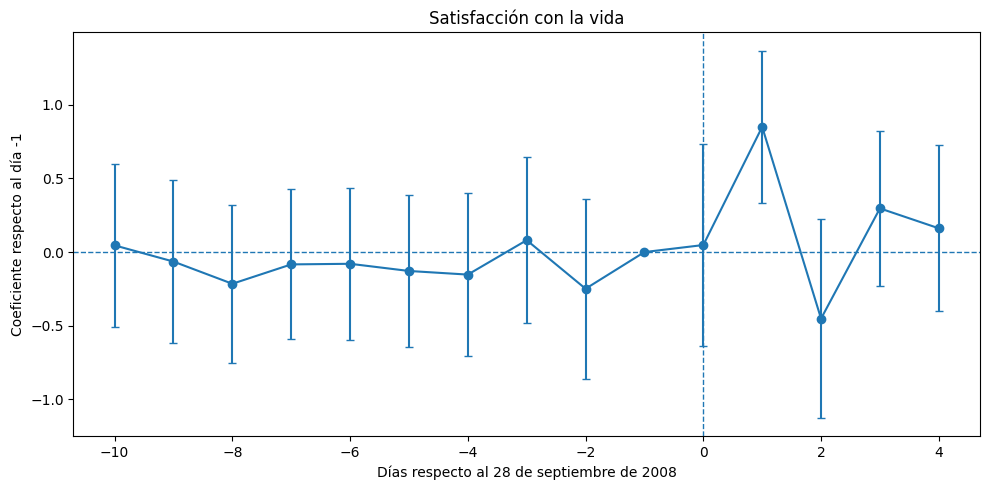

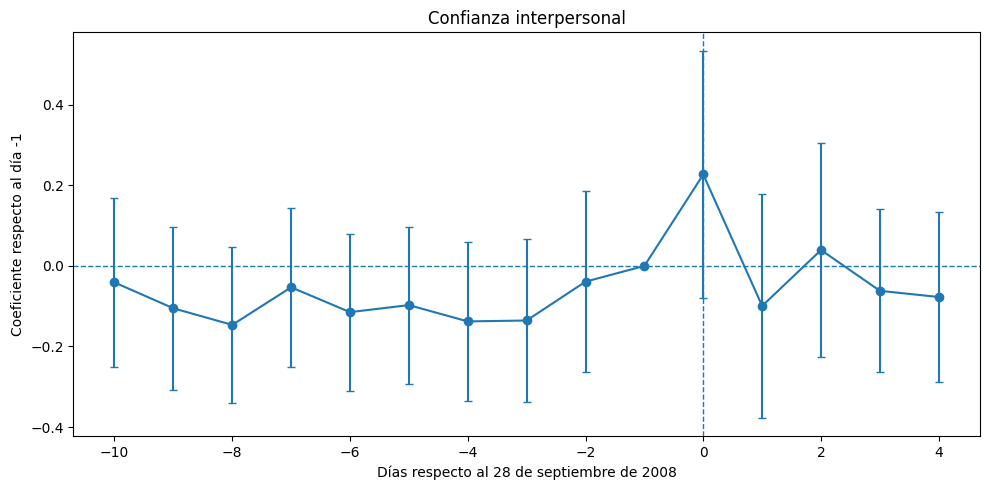

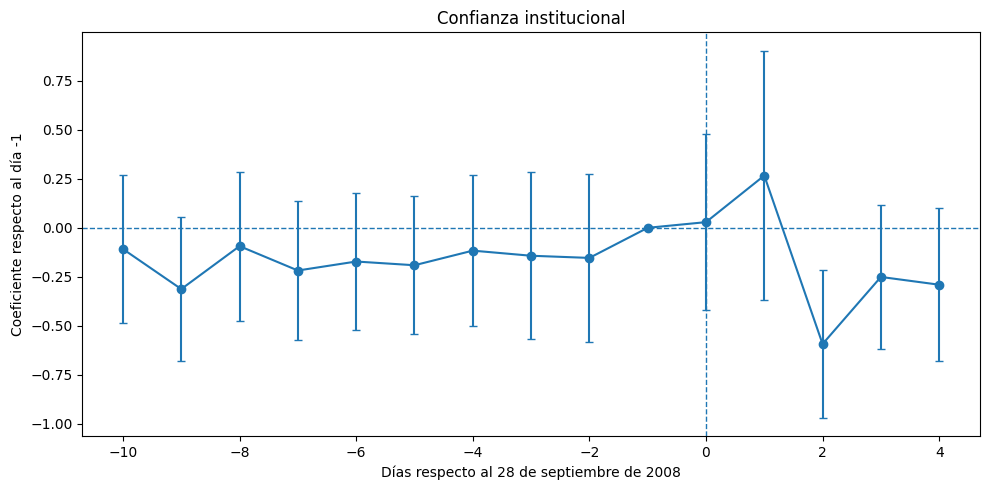

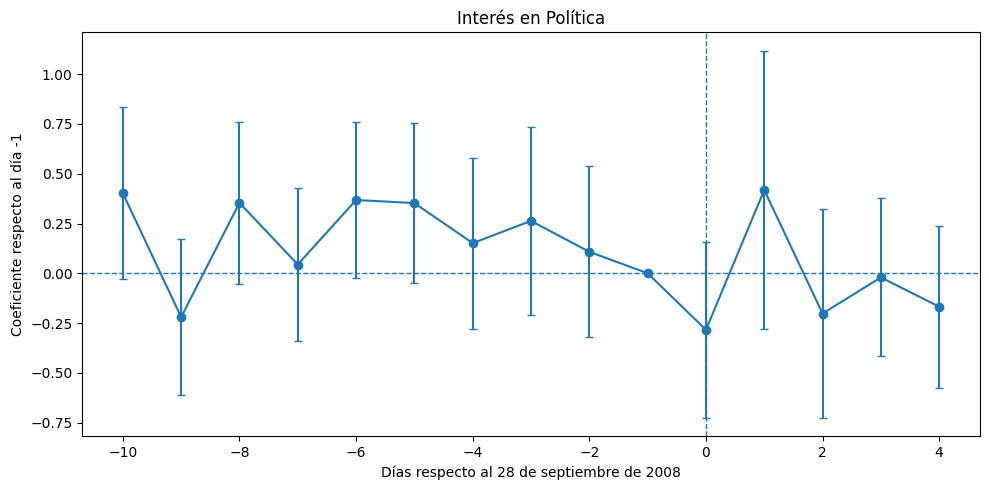


================ FELICIDAD ================

 dia      beta       se    ci_low  ci_high
 -10  0.045591 0.282523 -0.508155 0.599337
  -9 -0.064556 0.283629 -0.620469 0.491356
  -8 -0.215188 0.273164 -0.750590 0.320214
  -7 -0.083684 0.260110 -0.593500 0.426132
  -6 -0.079575 0.263564 -0.596160 0.437010
  -5 -0.128323 0.261743 -0.641340 0.384694
  -4 -0.152897 0.281315 -0.704273 0.398480
  -3  0.080696 0.288300 -0.484373 0.645764
  -2 -0.249003 0.312317 -0.861145 0.363138
  -1  0.000000 0.000000  0.000000 0.000000
   0  0.047820 0.351217 -0.640565 0.736204
   1  0.849993 0.263917  0.332715 1.367270
   2 -0.451895 0.343745 -1.125636 0.221846
   3  0.296611 0.269233 -0.231086 0.824307
   4  0.161391 0.288109 -0.403303 0.726085

================ CONFIANZA INTERPERSONAL ================

 dia      beta       se    ci_low  ci_high
 -10 -0.041035 0.106500 -0.249774 0.167705
  -9 -0.105263 0.102932 -0.307010 0.096483
  -8 -0.146424 0.098464 -0.339414 0.046566
  -7 -0.053119 0.100810 -0.250707 

In [22]:
# ============================================================
# ECUADOR
# Terremoto
#
# ============================================================

es = master[
    (master['country'] == 218) &
    (master['wave'] == 2023)
].copy()

es['fecha_entrevista'] = pd.to_datetime(
    dict(
        year=es['wave'],
        month=es['mes_real'],
        day=es['dia_real']
    ),
    errors='coerce'
)

# 1
fecha_evento = pd.Timestamp('2023-03-18')

es['dias_evento'] = (
    es['fecha_entrevista'] - fecha_evento
).dt.days

# Ventana: -10 a +10
es = es[
    es['dias_evento'].between(-10, 10)
].copy()


# ============================================================
# FUNCIÓN EVENT STUDY
# ============================================================

def event_study(variable, titulo):

    data = es.dropna(subset=[variable]).copy()

    X = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 = referencia
    if 'dia_-1' in X.columns:
        X = X.drop(columns='dia_-1')

    X = sm.add_constant(X)

    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    resultados = []

    for dia in range(-10, 10):

        if dia == -1:

            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

    r = pd.DataFrame(resultados)

    r['ci_low'] = r['beta'] - 1.96 * r['se']
    r['ci_high'] = r['beta'] + 1.96 * r['se']

    # ========================================================
    # GRÁFICO
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.errorbar(
        r['dia'],
        r['beta'],
        yerr=1.96 * r['se'],
        fmt='o-',
        capsize=3
    )

    plt.axhline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.axvline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.xlabel(
        'Días respecto al 28 de septiembre de 2008'
    )

    plt.ylabel(
        'Coeficiente respecto al día -1'
    )

    plt.title(titulo)

    plt.tight_layout()
    plt.show()

    return modelo, r


# ============================================================
# CUATRO EVENT STUDIES
# ============================================================

modelo_felicidad, resultados_felicidad = event_study(
    'life_satisfaction_z',
    'Satisfacción con la vida'
)

modelo_interpersonal, resultados_interpersonal = event_study(
    'trust_people',
    'Confianza interpersonal'
)

modelo_institucional, resultados_institucional = event_study(
    'confianza_institucional_z',
    'Confianza institucional'
)

modelo_interes, resultados_interes = event_study(
    'interest_politics_z',
    'Interés en Política'
)

# ============================================================
# IMPRIMIR COEFICIENTES
# ============================================================

pd.set_option('display.max_rows', 100)

print("\n================ FELICIDAD ================\n")
print(resultados_felicidad[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

print("\n================ CONFIANZA INTERPERSONAL ================\n")
print(resultados_interpersonal[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

print("\n================ CONFIANZA INSTITUCIONAL ================\n")
print(resultados_institucional[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))



## Nicaragua 2013 (breve aumento en felicidad, breve caida en confianza en las instituciones, breve aumento en confianza interpersonal)

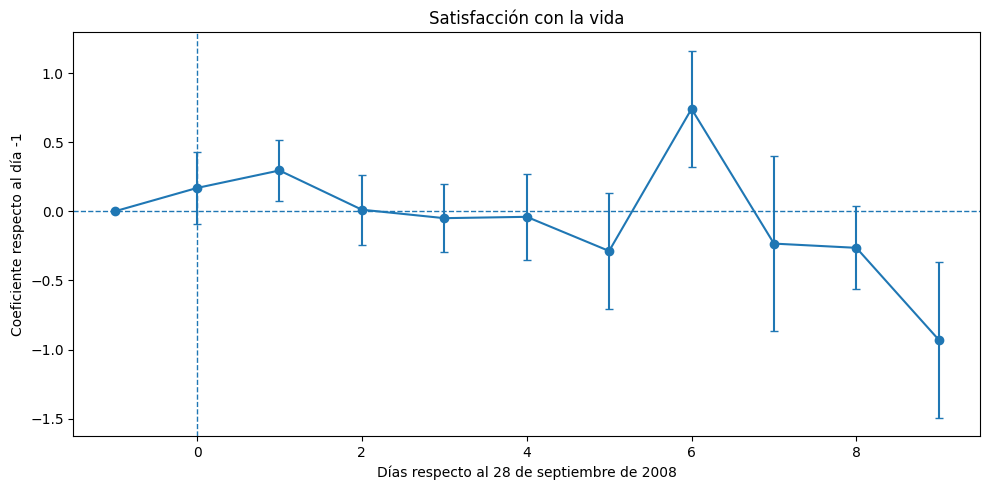

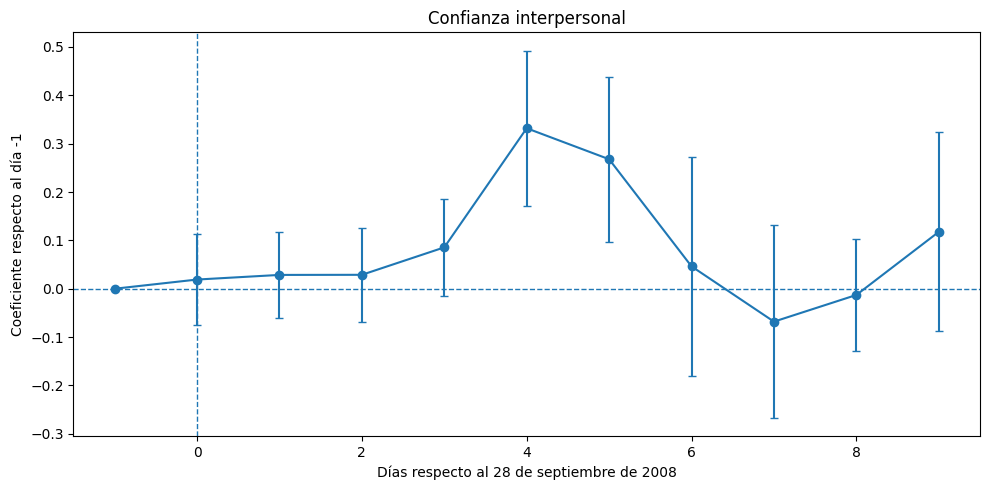

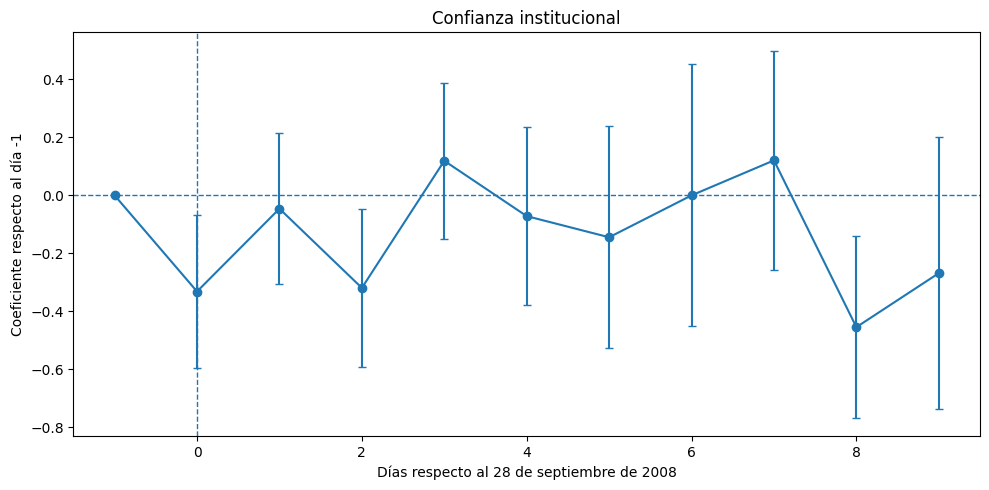

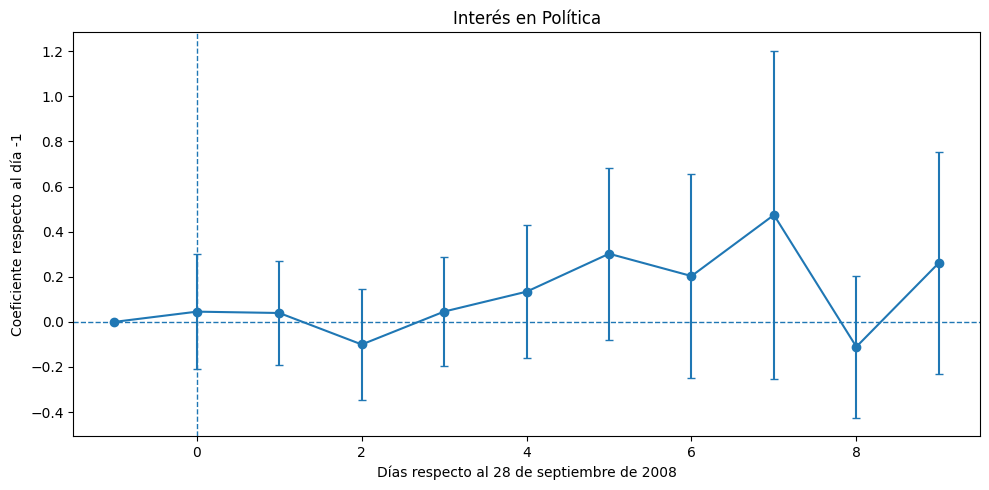


================ FELICIDAD ================

 dia      beta       se    ci_low   ci_high
  -1  0.000000 0.000000  0.000000  0.000000
   0  0.169340 0.133667 -0.092647  0.431326
   1  0.295853 0.113929  0.072552  0.519154
   2  0.012048 0.129326 -0.241430  0.265527
   3 -0.049226 0.126367 -0.296906  0.198454
   4 -0.039498 0.157832 -0.348848  0.269853
   5 -0.286750 0.212433 -0.703118  0.129618
   6  0.741373 0.214823  0.320320  1.162426
   7 -0.233202 0.323216 -0.866704  0.400301
   8 -0.263879 0.153227 -0.564204  0.036447
   9 -0.929327 0.288095 -1.493992 -0.364661

================ CONFIANZA INTERPERSONAL ================

 dia      beta       se    ci_low  ci_high
  -1  0.000000 0.000000  0.000000 0.000000
   0  0.018983 0.047955 -0.075008 0.112974
   1  0.028562 0.045720 -0.061049 0.118173
   2  0.028783 0.049524 -0.068283 0.125849
   3  0.085556 0.050805 -0.014022 0.185134
   4  0.331933 0.081848  0.171510 0.492356
   5  0.267830 0.087069  0.097175 0.438486
   6  0.046218 0.11567

In [23]:
# ============================================================
# NICARAGUA
# Terremoto
#
# ============================================================

es = master[
    (master['country'] == 558) &
    (master['wave'] == 2013)
].copy()

es['fecha_entrevista'] = pd.to_datetime(
    dict(
        year=es['wave'],
        month=es['mes_real'],
        day=es['dia_real']
    ),
    errors='coerce'
)

# 1
fecha_evento = pd.Timestamp('2013-06-15')

es['dias_evento'] = (
    es['fecha_entrevista'] - fecha_evento
).dt.days

# Ventana: -10 a +10
es = es[
    es['dias_evento'].between(-10, 10)
].copy()


# ============================================================
# FUNCIÓN EVENT STUDY
# ============================================================

def event_study(variable, titulo):

    data = es.dropna(subset=[variable]).copy()

    X = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 = referencia
    if 'dia_-1' in X.columns:
        X = X.drop(columns='dia_-1')

    X = sm.add_constant(X)

    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    resultados = []

    for dia in range(-10, 10):

        if dia == -1:

            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

    r = pd.DataFrame(resultados)

    r['ci_low'] = r['beta'] - 1.96 * r['se']
    r['ci_high'] = r['beta'] + 1.96 * r['se']

    # ========================================================
    # GRÁFICO
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.errorbar(
        r['dia'],
        r['beta'],
        yerr=1.96 * r['se'],
        fmt='o-',
        capsize=3
    )

    plt.axhline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.axvline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.xlabel(
        'Días respecto al 28 de septiembre de 2008'
    )

    plt.ylabel(
        'Coeficiente respecto al día -1'
    )

    plt.title(titulo)

    plt.tight_layout()
    plt.show()

    return modelo, r


# ============================================================
# CUATRO EVENT STUDIES
# ============================================================

modelo_felicidad, resultados_felicidad = event_study(
    'life_satisfaction_z',
    'Satisfacción con la vida'
)

modelo_interpersonal, resultados_interpersonal = event_study(
    'trust_people',
    'Confianza interpersonal'
)

modelo_institucional, resultados_institucional = event_study(
    'confianza_institucional_z',
    'Confianza institucional'
)

modelo_interes, resultados_interes = event_study(
    'interest_politics_z',
    'Interés en Política'
)

# ============================================================
# IMPRIMIR COEFICIENTES
# ============================================================

pd.set_option('display.max_rows', 100)

print("\n================ FELICIDAD ================\n")
print(resultados_felicidad[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

print("\n================ CONFIANZA INTERPERSONAL ================\n")
print(resultados_interpersonal[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

print("\n================ CONFIANZA INSTITUCIONAL ================\n")
print(resultados_institucional[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))



## Pooled

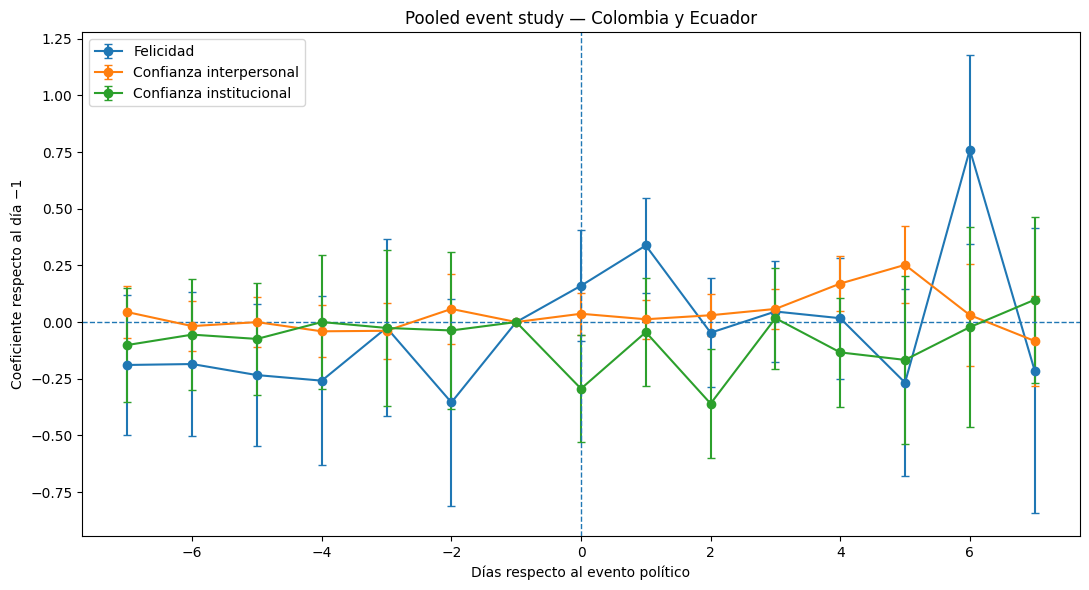

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


# ============================================================
# 1. CONSTRUIR EL POOLED
# ============================================================

casos = [
    {'country': 218,  'wave': 2023, 'evento': '2023-03-18', 'nombre': 'Ecuador'},
    {'country': 558, 'wave': 2013, 'evento': '2013-06-15', 'nombre': 'Nicaragua'}

]

dfs = []

for caso in casos:

    d = master[
        (master['country'] == caso['country']) &
        (master['wave'] == caso['wave'])
    ].copy()

    d['fecha_entrevista'] = pd.to_datetime(
        dict(
            year=d['wave'],
            month=d['mes_real'],
            day=d['dia_real']
        ),
        errors='coerce'
    )

    fecha_evento = pd.Timestamp(caso['evento'])

    d['dias_evento'] = (
        d['fecha_entrevista'] - fecha_evento
    ).dt.days

    d['pais_evento'] = caso['nombre']

    # Ventana común
    d = d[d['dias_evento'].between(-7, 7)].copy()

    dfs.append(d)

es_pool = pd.concat(dfs, ignore_index=True)


# ============================================================
# 2. EVENT STUDY POOLED CON EFECTOS FIJOS DE PAÍS
# ============================================================

def pooled_event_study(variable):

    data = es_pool.dropna(subset=[variable]).copy()

    # --------------------------------------------
    # Dummies de distancia al evento
    # --------------------------------------------

    X_evento = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 = referencia
    if 'dia_-1' in X_evento.columns:
        X_evento = X_evento.drop(columns='dia_-1')

    # --------------------------------------------
    # Efectos fijos de país/evento
    # --------------------------------------------

    X_pais = pd.get_dummies(
        data['pais_evento'],
        prefix='pais',
        drop_first=True,
        dtype=float
    )

    # --------------------------------------------
    # Matriz final
    # --------------------------------------------

    X = pd.concat(
        [X_evento, X_pais],
        axis=1
    )

    X = sm.add_constant(X)

    # --------------------------------------------
    # OLS
    # --------------------------------------------

    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    # --------------------------------------------
    # Extraer coeficientes
    # --------------------------------------------

    resultados = []

    for dia in range(-7, 8):

        if dia == -1:

            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

    r = pd.DataFrame(resultados)

    r['ci_low'] = (
        r['beta'] - 1.96 * r['se']
    )

    r['ci_high'] = (
        r['beta'] + 1.96 * r['se']
    )

    return modelo, r


# ============================================================
# 3. ESTIMAR LAS TRES VARIABLES
# ============================================================

modelo_fel, r_fel = pooled_event_study(
    'life_satisfaction_z'
)

modelo_inter, r_inter = pooled_event_study(
    'trust_people'
)

modelo_inst, r_inst = pooled_event_study(
    'confianza_institucional_z'
)


# ============================================================
# 4. GRÁFICO
# ============================================================

plt.figure(figsize=(11, 6))

plt.errorbar(
    r_fel['dia'],
    r_fel['beta'],
    yerr=1.96 * r_fel['se'],
    fmt='o-',
    capsize=3,
    label='Felicidad'
)

plt.errorbar(
    r_inter['dia'],
    r_inter['beta'],
    yerr=1.96 * r_inter['se'],
    fmt='o-',
    capsize=3,
    label='Confianza interpersonal'
)

plt.errorbar(
    r_inst['dia'],
    r_inst['beta'],
    yerr=1.96 * r_inst['se'],
    fmt='o-',
    capsize=3,
    label='Confianza institucional'
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Días respecto al evento político')
plt.ylabel('Coeficiente respecto al día −1')

plt.title(
    'Pooled event study — Colombia y Ecuador'
)

plt.legend()
plt.tight_layout()
plt.show()

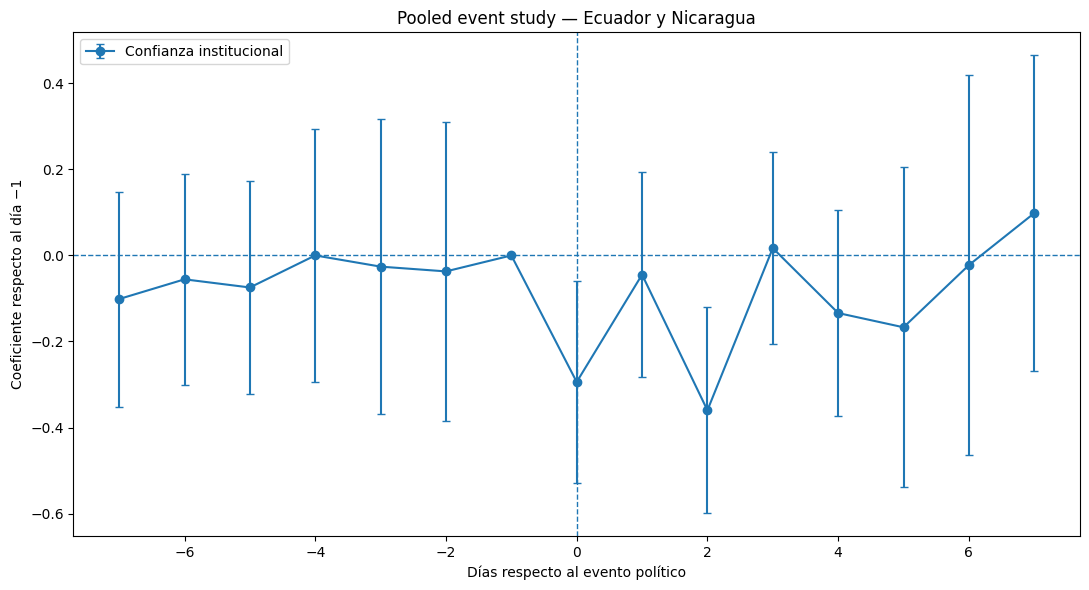

In [36]:
# ============================================================
# 4.1 SOLO CONFIANZA INSTITUCIONAL
# ============================================================

plt.figure(figsize=(11, 6))


plt.errorbar(
    r_inst['dia'],
    r_inst['beta'],
    yerr=1.96 * r_inst['se'],
    fmt='o-',
    capsize=3,
    label='Confianza institucional'
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Días respecto al evento político')
plt.ylabel('Coeficiente respecto al día −1')

plt.title(
    'Pooled event study — Ecuador y Nicaragua'
)

plt.legend()
plt.tight_layout()
plt.show()

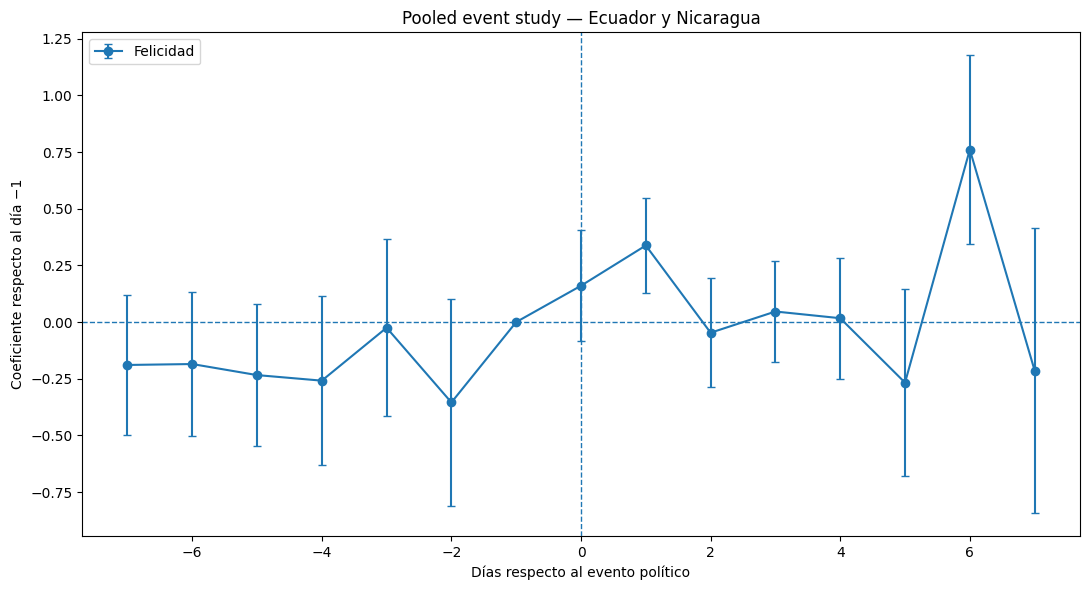

In [37]:
# ============================================================
# 4.1 SOLO FELICIDAD
# ============================================================

plt.figure(figsize=(11, 6))


plt.errorbar(
    r_fel['dia'],
    r_fel['beta'],
    yerr=1.96 * r_fel['se'],
    fmt='o-',
    capsize=3,
    label='Felicidad'
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Días respecto al evento político')
plt.ylabel('Coeficiente respecto al día −1')

plt.title(
    'Pooled event study — Ecuador y Nicaragua'
)

plt.legend()
plt.tight_layout()
plt.show()

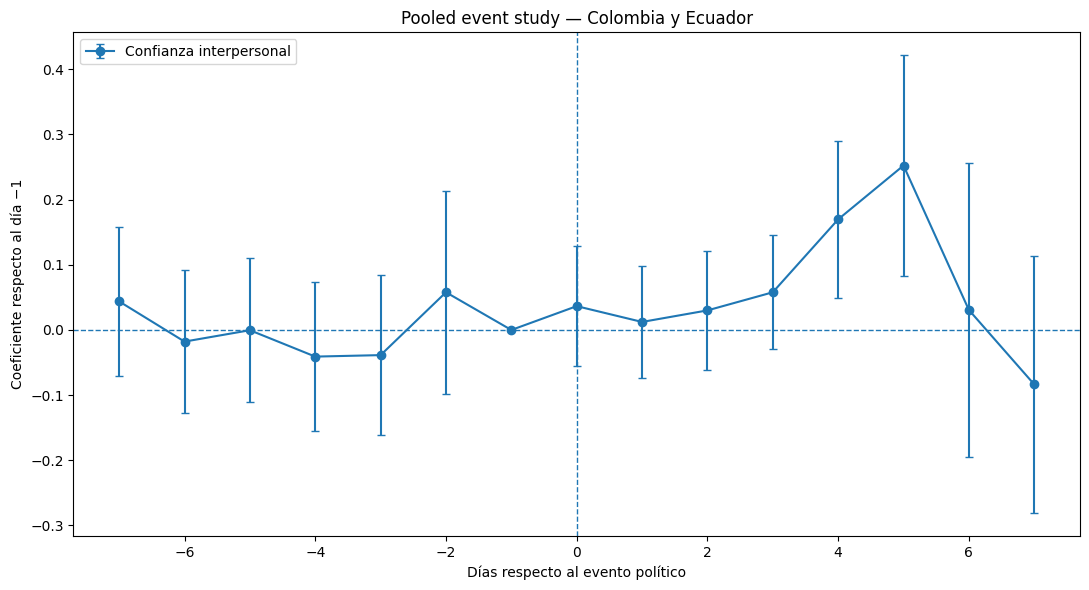

In [38]:
# ============================================================
# 4. GRÁFICO
# ============================================================

plt.figure(figsize=(11, 6))


plt.errorbar(
    r_inter['dia'],
    r_inter['beta'],
    yerr=1.96 * r_inter['se'],
    fmt='o-',
    capsize=3,
    label='Confianza interpersonal'
)



plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Días respecto al evento político')
plt.ylabel('Coeficiente respecto al día −1')

plt.title(
    'Pooled event study — Colombia y Ecuador'
)

plt.legend()
plt.tight_layout()
plt.show()

# Voto joven

In [24]:
# Solo Brasil y Nicaragua tienen datos de menores de 18. Son países que tienen voto desde antes de los 18 sin cambios en la legislación

nic_menores = master[
    (master['country'] == 558) &
    (master['age'].between(16, 17))
].copy()

tabla = (
    nic_menores
    .groupby(['wave', 'age'])['interest_politics_z']
    .agg(['count', 'mean', 'std'])
)

print(tabla.to_string())

           count      mean       std
wave age                            
1996 16.0     12  0.352372  1.141759
     17.0     22  0.376961  1.065420
2001 16.0     15  0.473348  1.166996
     17.0     21  0.304834  1.135631
2002 16.0      0       NaN       NaN
     17.0      0       NaN       NaN
2003 16.0     27  0.004104  1.095416
     17.0     38 -0.210822  0.881871
2004 16.0     37 -0.111963  0.965463
     17.0     40 -0.333538  0.893596
2005 16.0     43 -0.204578  0.740062
     17.0     29 -0.310373  0.910251
2006 16.0      0       NaN       NaN
     17.0      0       NaN       NaN
2007 16.0     59  0.110543  1.077139
     17.0     35  0.076821  1.121006
2008 16.0      0       NaN       NaN
     17.0      0       NaN       NaN
2009 16.0     19  0.193399  1.072479
     17.0     23 -0.567838  0.616575
2010 16.0     35 -0.166730  1.006971
     17.0     43 -0.071555  1.005514
2011 16.0      0       NaN       NaN
     17.0      0       NaN       NaN
2013 16.0     39 -0.102820  0.993601
 